In [1]:
import sys

import matplotlib
import matplotlib.pyplot
import numpy
import pandas
import scipy

sys.path.insert(0, "..")
from runner.utils import load_benchmark_metadata

# Load the results and metadata

In [2]:
# Read the latest results for all benchmarks.
all_results = pandas.read_csv("../results/benchmark_results.csv")

# Load the metadata of the benchmarks.
all_metadata = load_benchmark_metadata("../results/metadata.yaml")

# Add selected metadata columns to the results dataframe.
all_results["Variables"] = [
    all_metadata.loc[b, "Num. variables"] for b in all_results["bench-size"]
]
all_results["Constraints"] = [
    all_metadata.loc[b, "Num. constraints"] for b in all_results["bench-size"]
]
all_results["Non-zeros"] = [
    all_metadata.loc[b, "Num. nonzeros"] for b in all_results["bench-size"]
]
all_results["Problem class"] = [
    all_metadata.loc[b, "Problem class"] for b in all_results["bench-size"]
]
all_results["Modelling framework"] = [
    all_metadata.loc[b, "Modelling framework"] for b in all_results["bench-size"]
]

# Remove HiGHS-IPX and HiGHS-HiPO as they are not default options.
all_results = all_results[
    ~all_results["Solver"].isin(["highs-ipx", "highs-hipo"])
].copy()

# Display the first few rows of the results dataframe.
all_results.head()

,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,VM Zone,Solver benchmark version,bench-size,solver-version,Benchmark1,Variables,Constraints,Non-zeros,Problem class,Modelling framework
0,TIMES-GEO-global-netzero,31-20ts,gurobi,13.0.0,2025.0,ok,optimal,30621.769838,17795.476,2.173686e+08,...,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,gurobi-13.0.0,TIMES-GEO-global-netzero,5422595,5063755,30487085,LP,TIMES
3,TIMES-GEO-global-netzero,31-20ts,highs,1.12.0,2025.0,ER,unknown,62869.744979,17229.104,0.000000e+00,...,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,highs-1.12.0,TIMES-GEO-global-netzero,5422595,5063755,30487085,LP,TIMES
4,TIMES-GEO-global-netzero,31-20ts,scip,10.0.0,2025.0,TO,Timeout,86400.000000,39357.552,NaN,...,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,scip-10.0.0,TIMES-GEO-global-netzero,5422595,5063755,30487085,LP,TIMES
5,TIMES-GEO-global-netzero,31-20ts,cbc,2.10.12,2024.0,TO,Timeout,86400.000000,2498.936,NaN,...,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,cbc-2.10.12,TIMES-GEO-global-netzero,5422595,5063755,30487085,LP,TIMES
6,pypsa-de-elec,50-1h,gurobi,13.0.0,2025.0,ok,optimal,2989.140083,27867.236,5.649368e+09,...,us-east5-a,90fca5f,pypsa-de-elec-50-1h,gurobi-13.0.0,pypsa-de-elec,8672926,18458019,35789890,LP,PyPSA


In [3]:
# Read the pypsa-de-elec results from the CSV file.
pypsa_de_elec_results = pandas.read_csv(
    "../results/benchmark_results_pypsa_de_elec_scaling.csv"
)

# Add selected metadata columns to the pypsa-de-elec results dataframe.
pypsa_de_elec_results["Variables"] = [
    all_metadata.loc[b, "Num. variables"] for b in pypsa_de_elec_results["bench-size"]
]
pypsa_de_elec_results["Constraints"] = [
    all_metadata.loc[b, "Num. constraints"] for b in pypsa_de_elec_results["bench-size"]
]
pypsa_de_elec_results["Problem class"] = [
    all_metadata.loc[b, "Problem class"] for b in pypsa_de_elec_results["bench-size"]
]
pypsa_de_elec_results["Temporal resolution"] = pypsa_de_elec_results["Size"].apply(
    lambda x: x.split("-")[1]
)
pypsa_de_elec_results["Spatial resolution"] = pypsa_de_elec_results["Size"].apply(
    lambda x: int(x.split("-")[0])
)

# Display the first few rows of the pypsa-de-elec results dataframe.
pypsa_de_elec_results.head()

,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,Timestamp,VM Instance Type,VM Zone,Solver benchmark version,bench-size,Variables,Constraints,Problem class,Temporal resolution,Spatial resolution
0,pypsa-de-elec,2-1h,cbc,2.10.12,2024.0,ok,optimal,1237.209032,879.560,5.028012e+09,...,2026-03-03 10:20:46.322200,c4-standard-8,us-central1-a,8b506ef,pypsa-de-elec-2-1h,569341,1165120,LP,1h,2
1,pypsa-de-elec,2-1h,gurobi,12.0.0,2024.0,ok,optimal,15.891824,1961.844,5.028012e+09,...,2026-03-03 10:45:19.716497,c4-standard-8,us-central1-a,8b506ef,pypsa-de-elec-2-1h,569341,1165120,LP,1h,2
2,pypsa-de-elec,2-1h,highs,1.9.0,2024.0,ok,optimal,591.795680,1776.204,5.028012e+09,...,2026-03-03 10:45:43.370124,c4-standard-8,us-central1-a,8b506ef,pypsa-de-elec-2-1h,569341,1165120,LP,1h,2
3,pypsa-de-elec,2-1h,gurobi,13.0.0,2025.0,ok,optimal,15.858992,1987.588,5.028012e+09,...,2026-03-03 10:56:13.137230,c4-standard-8,us-central1-a,8b506ef,pypsa-de-elec-2-1h,569341,1165120,LP,1h,2
4,pypsa-de-elec,2-1h,highs-hipo,1.12.0-hipo,2025.0,ok,Optimal,194.748873,1278.044,5.028012e+09,...,2026-03-03 11:00:15.646915,c4-standard-8,us-central1-a,8b506ef,pypsa-de-elec-2-1h,569341,1165120,LP,1h,2


In [4]:
# Read the pypsa-de-elec-uc results from the CSV file.
pypsa_de_elec_uc_results = pandas.read_csv(
    "../results/benchmark_results_pypsa_de_elec_uc_scaling.csv"
)

# Add selected metadata columns to the pypsa-de-elec-uc results dataframe.
pypsa_de_elec_uc_results["Variables"] = [
    all_metadata.loc[b, "Num. variables"]
    for b in pypsa_de_elec_uc_results["bench-size"]
]
pypsa_de_elec_uc_results["Continuous variables"] = [
    all_metadata.loc[b, "Num. continuous variables"]
    for b in pypsa_de_elec_uc_results["bench-size"]
]
pypsa_de_elec_uc_results["Integer variables"] = [
    all_metadata.loc[b, "Num. integer variables"]
    for b in pypsa_de_elec_uc_results["bench-size"]
]
pypsa_de_elec_uc_results["Constraints"] = [
    all_metadata.loc[b, "Num. constraints"]
    for b in pypsa_de_elec_uc_results["bench-size"]
]
pypsa_de_elec_uc_results["Problem class"] = [
    all_metadata.loc[b, "Problem class"] for b in pypsa_de_elec_uc_results["bench-size"]
]
pypsa_de_elec_uc_results["Temporal resolution"] = pypsa_de_elec_uc_results[
    "Size"
].apply(lambda x: int(x.split("-")[1].strip("h")))
pypsa_de_elec_uc_results["Spatial resolution"] = pypsa_de_elec_uc_results["Size"].apply(
    lambda x: int(x.split("-")[0])
)

# Display the first few rows of the pypsa-de-elec-uc results dataframe.
pypsa_de_elec_uc_results.head()

,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,VM Zone,Solver benchmark version,bench-size,Variables,Continuous variables,Integer variables,Constraints,Problem class,Temporal resolution,Spatial resolution
0,pypsa-de-elec-uc,2-5h,gurobi,13.0.0,2025.0,ok,optimal,1985.747551,6250.112,5.069958e+09,...,us-central1-a,53fb046,pypsa-de-elec-uc-2-5h,155943,113895.0,42048.0,296128,MILP,5,2
1,pypsa-de-elec-uc,2-5h,highs,1.12.0,2025.0,TO,Timeout,86400.000000,7443.604,NaN,...,us-central1-a,53fb046,pypsa-de-elec-uc-2-5h,155943,113895.0,42048.0,296128,MILP,5,2
2,pypsa-de-elec-uc,2-5h,scip,10.0.0,2025.0,TO,Timeout,86400.000000,13630.732,NaN,...,us-central1-a,53fb046,pypsa-de-elec-uc-2-5h,155943,113895.0,42048.0,296128,MILP,5,2
3,pypsa-de-elec-uc,2-5h,cbc,2.10.12,2024.0,TO,Timeout,86400.000000,200.932,NaN,...,us-central1-a,53fb046,pypsa-de-elec-uc-2-5h,155943,113895.0,42048.0,296128,MILP,5,2
4,pypsa-de-elec-uc,2-8h,gurobi,13.0.0,2025.0,ok,optimal,5496.629968,4941.700,5.067184e+09,...,us-central1-a,53fb046,pypsa-de-elec-uc-2-8h,97476,71196.0,26280.0,185095,MILP,8,2


# Define color, marker, and name mappings for solvers

In [5]:
# Define the color map for the solvers.
color_map = {
    "cbc": "#F9CD5A",  # yellow
    "glpk": "#7C3AED",  # purple
    "gurobi": "#F66C49",  # red
    "highs": "#43BF94",  # green
    "scip": "#3B82F6",  # blue
}

# Define the marker map for the solvers.
marker_map = {
    "cbc": "o",  # yellow
    "glpk": "s",  # purple
    "gurobi": "d",  # red
    "highs": "^",  # green
    "scip": "X",  # blue
}

# Define the name map for the solvers.
name_map = {
    "cbc": "CBC",
    "glpk": "GLPK",
    "gurobi": "Gurobi",
    "highs": "HiGHS",
    "scip": "SCIP",
}

# Analyze the benchmark set

In [6]:
# Compute the number of problems.
all_results["bench-size"].nunique()

213

In [7]:
# Compute the number of LP and MIP problems.
all_results.groupby("Problem class")["bench-size"].nunique()

Problem class
LP      133
MILP     80
Name: bench-size, dtype: int64

In [8]:
# Compute the number of problems by modelling framework.
all_results.groupby("Modelling framework")["bench-size"].nunique()

Modelling framework
DCOPF           4
ETHOS.FINE     13
GenX           20
IESA-Opt        3
OEMOF          13
PowerModels     5
PyPSA          80
SWITCH         10
Sienna         36
TEMOA           6
TIMES          15
Tulipa          6
ZEN-garden      2
Name: bench-size, dtype: int64

In [9]:
# Group the model frameworks "DCOPF", "IESA-Opt", "PowerModels", and "ZEN-garden" into a single category "Others".
all_results["Modelling framework"] = all_results["Modelling framework"].replace(
    {
        "DCOPF": "Others",
        "IESA-Opt": "Others",
        "PowerModels": "Others",
        "ZEN-garden": "Others",
    }
)

In [10]:
# Get the unique solver versions and their corresponding release years.
solver_versions = all_results.groupby("solver-version")["Solver Release Year"].unique()

# Check that each solver version corresponds to a unique release year.
assert solver_versions.apply(lambda x: len(x) == 1).all(), (
    "Each solver version should have a unique release year."
)

# Extract the release year from the unique values in the solver_versions series.
solver_versions = solver_versions.apply(lambda x: int(x[0]))

# Create a multi index for the solver versions.
solver_versions.index = solver_versions.index.str.split("-", n=1, expand=True)
solver_versions.index.names = ["solver", "version"]

solver_versions

solver  version   
cbc     2.10.11       2023
        2.10.12       2024
glpk    5.0           2020
gurobi  10.0.0        2022
        11.0.0        2023
        12.0.0        2024
        13.0.0        2025
highs   1.12.0        2025
        1.5.0.dev0    2022
        1.6.0.dev0    2023
        1.9.0         2024
scip    10.0.0        2025
        8.0.3         2022
        8.1.0         2023
        9.2.0         2024
Name: Solver Release Year, dtype: int64

# Analyze the solver performance by grouping by number of variables and problem class

In [11]:
# Initialize a list to store the results obtained with the latest version of each solver.
latest_solver_results = []

for solver in all_results["Solver"].unique():
    # Filter the results for the current solver.
    filtered_results = all_results[(all_results["Solver"] == solver)].copy()

    # Keep only the latest version of the solver.
    filtered_results = filtered_results[
        filtered_results["Solver Release Year"]
        == filtered_results["Solver Release Year"].max()
    ].copy()

    # Append the filtered results to the list.
    latest_solver_results.append(filtered_results)

# Concatenate the results obtained with the latest version of each solver into a single dataframe.
latest_solver_results = pandas.concat(
    latest_solver_results, ignore_index=True
).reset_index(drop=True)

In [12]:
# Define the buckets for the number of variables.
buckets = {
    "LP": {
        "$10^2$-$10^4$": (1e2, 1e4),
        "$10^4$-$10^5$": (1e4, 1e5),
        "$10^5$-$10^6$": (1e5, 1e6),
        "$10^6$-$10^8$": (1e6, 1e8),
    },
    "MILP": {
        "$10^2$-$10^4$": (1e2, 1e4),
        "$10^4$-$10^5$": (1e4, 1e5),
        "$10^5$-$10^6$": (1e5, 1e6),
        "$10^6$-$10^8$": (1e6, 1e8),
    },
}

# Define the features to compute for each bucket.
features = [
    "num_problems",
    "fraction_solved",
    "sgm_runtime",
    "relative_sgm_runtime",
    "relative_sgm_runtime_rank",
]

# Define the shift to apply to the runtime when computing the SGM runtime.
sgm_shift = 10

# Initialize the bucket stats dictionary.
bucket_stats = {
    problem_type: {
        feature: {
            solver: {bucket: numpy.nan for bucket in buckets[problem_type]}
            for solver in latest_solver_results["Solver"].unique()
        }
        for feature in features
    }
    for problem_type in latest_solver_results["Problem class"].unique()
}

for problem_type in latest_solver_results["Problem class"].unique():
    for bucket_name, (bucket_min, bucket_max) in buckets[problem_type].items():
        for solver in latest_solver_results["Solver"].unique():
            # Filter the results for the current problem type, bucket, and solver.
            filtered_results = latest_solver_results[
                (latest_solver_results["Problem class"] == problem_type)
                & (latest_solver_results["Variables"] >= bucket_min)
                & (latest_solver_results["Variables"] < bucket_max)
                & (latest_solver_results["Solver"] == solver)
            ].copy()

            # Compute the number of problems.
            bucket_stats[problem_type]["num_problems"][solver][bucket_name] = len(
                filtered_results
            )

            # Identify the problems where the solver succeeded.
            is_solved = (filtered_results["Status"] == "ok") | (
                (filtered_results["Status"] == "warning")
                & (~filtered_results["Objective Value"].isna())
            )

            # Extract the problems where the solver succeeded.
            filtered_results_solved = filtered_results[is_solved]

            # Compute the fraction of problems solved.
            if len(filtered_results) > 0:
                bucket_stats[problem_type]["fraction_solved"][solver][bucket_name] = (
                    len(filtered_results_solved) / len(filtered_results)
                )

            # Assign the timeout threshold to unsolved problems to compute the SGM runtime.
            filtered_results["Runtime (s)"] = filtered_results["Runtime (s)"].where(
                is_solved, filtered_results["Timeout"]
            )

            # Compute the SGM runtime.
            bucket_stats[problem_type]["sgm_runtime"][solver][bucket_name] = (
                numpy.exp(
                    numpy.mean(numpy.log(filtered_results["Runtime (s)"] + sgm_shift))
                )
                - sgm_shift
            )

for problem_type in latest_solver_results["Problem class"].unique():
    for bucket in buckets[problem_type].keys():
        # Check if there are any problems available by checking the Gurobi results.
        if bucket_stats[problem_type]["num_problems"]["gurobi"][bucket] > 0:
            # Extrac the SGM runtimes of all solvers for the current problem type and bucket.
            solver_sgm_runtimes = bucket_stats[problem_type]["sgm_runtime"]

            # Find the solver with the largest SGM runtime in the current bucket.
            reference_solver = min(
                latest_solver_results["Solver"].unique(),
                key=lambda solver: solver_sgm_runtimes[solver][bucket],
            )

            for solver in latest_solver_results["Solver"].unique():
                # Compute the relative SGM runtime of each solver with respect to the reference solver.
                bucket_stats[problem_type]["relative_sgm_runtime"][solver][bucket] = (
                    bucket_stats[problem_type]["sgm_runtime"][solver][bucket]
                    / bucket_stats[problem_type]["sgm_runtime"][reference_solver][
                        bucket
                    ]
                )

for problem_type in latest_solver_results["Problem class"].unique():
    for bucket in buckets[problem_type].keys():
        # Extract the relative SGM runtimes of all solvers for the current problem type and bucket.
        solver_relative_sgm_runtimes = bucket_stats[problem_type][
            "relative_sgm_runtime"
        ]

        # Rank the solvers based on their relative SGM runtime in the current bucket.
        sorted_solvers = sorted(
            latest_solver_results["Solver"].unique(),
            key=lambda solver: solver_relative_sgm_runtimes[solver][bucket],
        )

        for rank, solver in enumerate(sorted_solvers, start=1):
            # Store the rank of each solver based on its relative SGM runtime.
            bucket_stats[problem_type]["relative_sgm_runtime_rank"][solver][bucket] = (
                rank
            )

In [13]:
# Get the number of problems in each bucket for each solver.
num_problems_per_bucket = {
    problem_type: {
        solver: list(stats.values())
        for solver, stats in bucket_stats[problem_type]["num_problems"].items()
    }
    for problem_type in latest_solver_results["Problem class"].unique()
}
num_problems_per_bucket

{'LP': {'gurobi': [8, 25, 41, 59],
  'highs': [8, 25, 41, 59],
  'scip': [8, 25, 41, 59],
  'cbc': [8, 25, 41, 59],
  'glpk': [8, 25, 41, 0]},
 'MILP': {'gurobi': [27, 37, 14, 2],
  'highs': [27, 37, 14, 2],
  'scip': [27, 37, 14, 2],
  'cbc': [27, 37, 14, 2],
  'glpk': [27, 37, 14, 0]}}

# Analyze the solver performance by gruping by modelling framework

In [14]:
# Define the features to compute for each bucket.
features = [
    "num_lp_problems",
    "num_milp_problems",
    "number_of_variables",
    "median_number_of_variables",
    "fraction_solved_by_any_solver",
    "fraction_solved_by_any_open_source_solver",
    "sgm_runtime_of_best_solver",
    "sgm_runtime_of_best_open_source_solver",
]

# Initialize the dictionary to store the results by modelling framework.
model_framework_stats = {
    feature: {
        model_framework: numpy.nan
        for model_framework in latest_solver_results["Modelling framework"].unique()
    }
    for feature in features
}

for model_framework in latest_solver_results["Modelling framework"].unique():
    # Filter the results for the current modelling framework.
    filtered_results = latest_solver_results[
        latest_solver_results["Modelling framework"] == model_framework
    ].copy()

    # Compute the number of problems.
    model_framework_stats["num_lp_problems"][model_framework] = len(
        filtered_results[filtered_results["Problem class"] == "LP"][
            "bench-size"
        ].unique()
    )
    model_framework_stats["num_milp_problems"][model_framework] = len(
        filtered_results[filtered_results["Problem class"] == "MILP"][
            "bench-size"
        ].unique()
    )

    # Extract a list of the number of variables for each problem.
    model_framework_stats["number_of_variables"][model_framework] = (
        filtered_results.groupby("bench-size")["Variables"].mean().to_list()
    )

    # Compute the median number of variables.
    model_framework_stats["median_number_of_variables"][model_framework] = (
        filtered_results.groupby("bench-size")["Variables"].mean().median()
    )

    # Grup the results by problem and check if each problem was solved by any solver.
    is_solved_by_any_solver = filtered_results.groupby("bench-size").apply(
        lambda x: (
            (x["Status"] == "ok").any()
            or ((x["Status"] == "warning") & (~x["Objective Value"].isna())).any()
        )
    )

    # Compute the fraction of problems solved by any solver.
    model_framework_stats["fraction_solved_by_any_solver"][model_framework] = (
        is_solved_by_any_solver.mean()
    )

    # Identify the problems that were solved by any solver.
    is_solved = (filtered_results["Status"] == "ok") | (
        (filtered_results["Status"] == "warning")
        & (~filtered_results["Objective Value"].isna())
    )

    # Assign the timeout threshold to unsolved problems to compute the SGM runtime.
    filtered_results["Runtime (s)"] = filtered_results["Runtime (s)"].where(
        is_solved, filtered_results["Timeout"]
    )

    # For each problem, find the best runtime among all solvers.
    best_runtime_per_problem = filtered_results.groupby("bench-size")[
        "Runtime (s)"
    ].min()

    # Compute the SGM runtime of the best solver for each problem.
    model_framework_stats["sgm_runtime_of_best_solver"][model_framework] = (
        numpy.exp(numpy.mean(numpy.log(best_runtime_per_problem + sgm_shift)))
        - sgm_shift
    )

    # Filter the results to keep only the open-source solvers.
    open_source_solvers = ["cbc", "glpk", "highs", "scip"]
    filtered_results_open_source = filtered_results[
        filtered_results["Solver"].isin(open_source_solvers)
    ]

    # Identify the problems that were solved by any open-source solver.
    is_solved_by_any_open_source_solver = filtered_results_open_source.groupby(
        "bench-size"
    ).apply(
        lambda x: (
            (x["Status"] == "ok").any()
            or ((x["Status"] == "warning") & (~x["Objective Value"].isna())).any()
        )
    )

    # Compute the fraction of problems solved by any open-source solver.
    model_framework_stats["fraction_solved_by_any_open_source_solver"][
        model_framework
    ] = is_solved_by_any_open_source_solver.mean()

    # For each problem, find the best runtime among all open-source solvers.
    best_runtime_per_problem_open_source = filtered_results_open_source.groupby(
        "bench-size"
    )["Runtime (s)"].min()

    # Compute the SGM runtime of the best open-source solver for each problem.
    model_framework_stats["sgm_runtime_of_best_open_source_solver"][model_framework] = (
        numpy.exp(
            numpy.mean(numpy.log(best_runtime_per_problem_open_source + sgm_shift))
        )
        - sgm_shift
    )

# Sort all the features by the median number of variables.
for feature in features:
    model_framework_stats[feature] = dict(
        sorted(
            model_framework_stats[feature].items(),
            key=lambda item: model_framework_stats["median_number_of_variables"][
                item[0]
            ],
        )
    )

# Analyze the solver performance evolution over time

In [15]:
# Create a multi index with solver name, version, and release year.
index = (
    solver_versions.reset_index()
    .set_index(["solver", "version", "Solver Release Year"])
    .rename_axis(index={"Solver Release Year": "release_year"})
    .index
)

# Initialize the performance evolution dictionary.
performance_evolution = pandas.DataFrame(
    index=index,
    columns=["fraction_solved", "sgm_runtime"],
)

for solver, version, year in performance_evolution.index:
    # Filter the results for the current solver version and problems with less than 10^6 variables.
    filtered_results = all_results[
        (all_results["solver-version"] == solver + "-" + version)
        & (all_results["Variables"] < 1e6)
    ].copy()

    # Identify the problems where the solver succeeded.
    is_solved = (filtered_results["Status"] == "ok") | (
        (filtered_results["Status"] == "warning")
        & (~filtered_results["Objective Value"].isna())
    )

    # Extract the problems where the solver succeeded.
    filtered_results_solved = filtered_results[is_solved]

    # Compute the fraction of problems solved.
    if len(filtered_results) > 0:
        performance_evolution.loc[(solver, version, year), "fraction_solved"] = len(
            filtered_results_solved
        ) / len(filtered_results)

    # Assign the timeout threshold to unsolved problems to compute the SGM runtime.
    filtered_results["Runtime (s)"] = filtered_results["Runtime (s)"].where(
        is_solved, filtered_results["Timeout"]
    )

    # Compute the SGM runtime.
    performance_evolution.loc[(solver, version, year), "sgm_runtime"] = (
        numpy.exp(numpy.mean(numpy.log(filtered_results["Runtime (s)"] + sgm_shift)))
        - sgm_shift
    )

# Sort the performance evolution dataframe by solver and release year.
performance_evolution = performance_evolution.sort_index(
    level=["solver", "release_year"]
)

performance_evolution

fraction_solved  sgm_runtime
solver version    release_year                             
cbc    2.10.11    2023                0.546053    453.53174
       2.10.12    2024                0.546053   456.928077
glpk   5.0        2020                0.315789  1412.172931
gurobi 10.0.0     2022                0.828947    104.87587
       11.0.0     2023                0.835526   102.968326
       12.0.0     2024                0.835526   103.719601
       13.0.0     2025                0.828947    101.16095
highs  1.5.0.dev0 2022                0.644737   269.281541
       1.6.0.dev0 2023                0.638158   266.468057
       1.9.0      2024                0.644737   267.024821
       1.12.0     2025                0.657895   263.290272
scip   8.0.3      2022                0.631579   398.757925
       8.1.0      2023                0.631579   397.864161
       9.2.0      2024                0.631579   398.707912
       10.0.0     2025                0.631579   398.251468

# Analyze the number of variables, non-zeros, and constraints

In [16]:
# Remove any rows with missing values.
valid_latest_solver_results = latest_solver_results.dropna(
    subset=["Variables", "Constraints", "Non-zeros"]
)

# Extract the number of variables, non-zeros, and constraints and apply log10 transformation to them.
log_variables = numpy.log10(
    valid_latest_solver_results.groupby("bench-size")["Variables"].mean()
)
log_non_zeros = numpy.log10(
    valid_latest_solver_results.groupby("bench-size")["Non-zeros"].mean()
)
log_constraints = numpy.log10(
    valid_latest_solver_results.groupby("bench-size")["Constraints"].mean()
)

In [17]:
# Perform a linear regression in log-log scale to find the exponent relating the number of variables and non-zeros.
slope_1, intercept_1, r_value_1, p_value_1, std_err_1 = scipy.stats.linregress(
    log_variables, log_non_zeros
)
slope_1, intercept_1, r_value_1, p_value_1, std_err_1

(np.float64(0.9954357128089141),
 np.float64(0.6728501640513613),
 np.float64(0.9901272201697698),
 np.float64(4.8847597732383524e-182),
 np.float64(0.009701550213794747))

In [18]:
# Perform a linear regression in log-log scale to find the exponent relating the number of variables and constraints.
slope_2, intercept_2, r_value_2, p_value_2, std_err_2 = scipy.stats.linregress(
    log_variables, log_constraints
)
slope_2, intercept_2, r_value_2, p_value_2, std_err_2

(np.float64(1.038271933566958),
 np.float64(-0.022677208905246715),
 np.float64(0.9918800556978088),
 np.float64(5.927945738449419e-191),
 np.float64(0.009164712502727934))

# Analyze the PyPSA-DE scaling benchmarks

In [19]:
# Make sure that all problems are the correct problem class.
assert (pypsa_de_elec_results["Problem class"] == "LP").all()
assert (pypsa_de_elec_uc_results["Problem class"] == "MILP").all()

# Initialize a list to store the latest version for each solver.
latest_versions_pypsa_de_elec_results = []

for solver in pypsa_de_elec_results["Solver"].unique():
    # Filter results for the current solver.
    solver_results = pypsa_de_elec_results[
        pypsa_de_elec_results["Solver"] == solver
    ].copy()

    # Keep only the latest version of the solver.
    solver_results = solver_results[
        solver_results["Solver Release Year"]
        == solver_results["Solver Release Year"].max()
    ]

    # Append the results of the latest version to the list.
    latest_versions_pypsa_de_elec_results.append(solver_results)

# Concatenate the results of the latest versions of all solvers into a single DataFrame.
pypsa_de_elec_results = pandas.concat(
    latest_versions_pypsa_de_elec_results, ignore_index=True
)

# Sort the results by spatial resolution.
pypsa_de_elec_results = pypsa_de_elec_results.sort_values(by="Spatial resolution")

# Initialize a list to store the latest version for each solver.
latest_versions_pypsa_de_elec_uc_results = []

for solver in pypsa_de_elec_uc_results["Solver"].unique():
    # Filter results for the current solver.
    solver_results = pypsa_de_elec_uc_results[
        pypsa_de_elec_uc_results["Solver"] == solver
    ].copy()

    # Keep only the latest version of the solver.
    solver_results = solver_results[
        solver_results["Solver Release Year"]
        == solver_results["Solver Release Year"].max()
    ]

    # Append the results of the latest version to the list.
    latest_versions_pypsa_de_elec_uc_results.append(solver_results)

# Concatenate the results of the latest versions of all solvers into a single DataFrame.
pypsa_de_elec_uc_results = pandas.concat(
    latest_versions_pypsa_de_elec_uc_results, ignore_index=True
)

# Sort the results by spatial resolution.
pypsa_de_elec_uc_results = pypsa_de_elec_uc_results.sort_values(
    by="Temporal resolution"
)

# Plot the fraction of solved problems by solver, problem class, and problem size

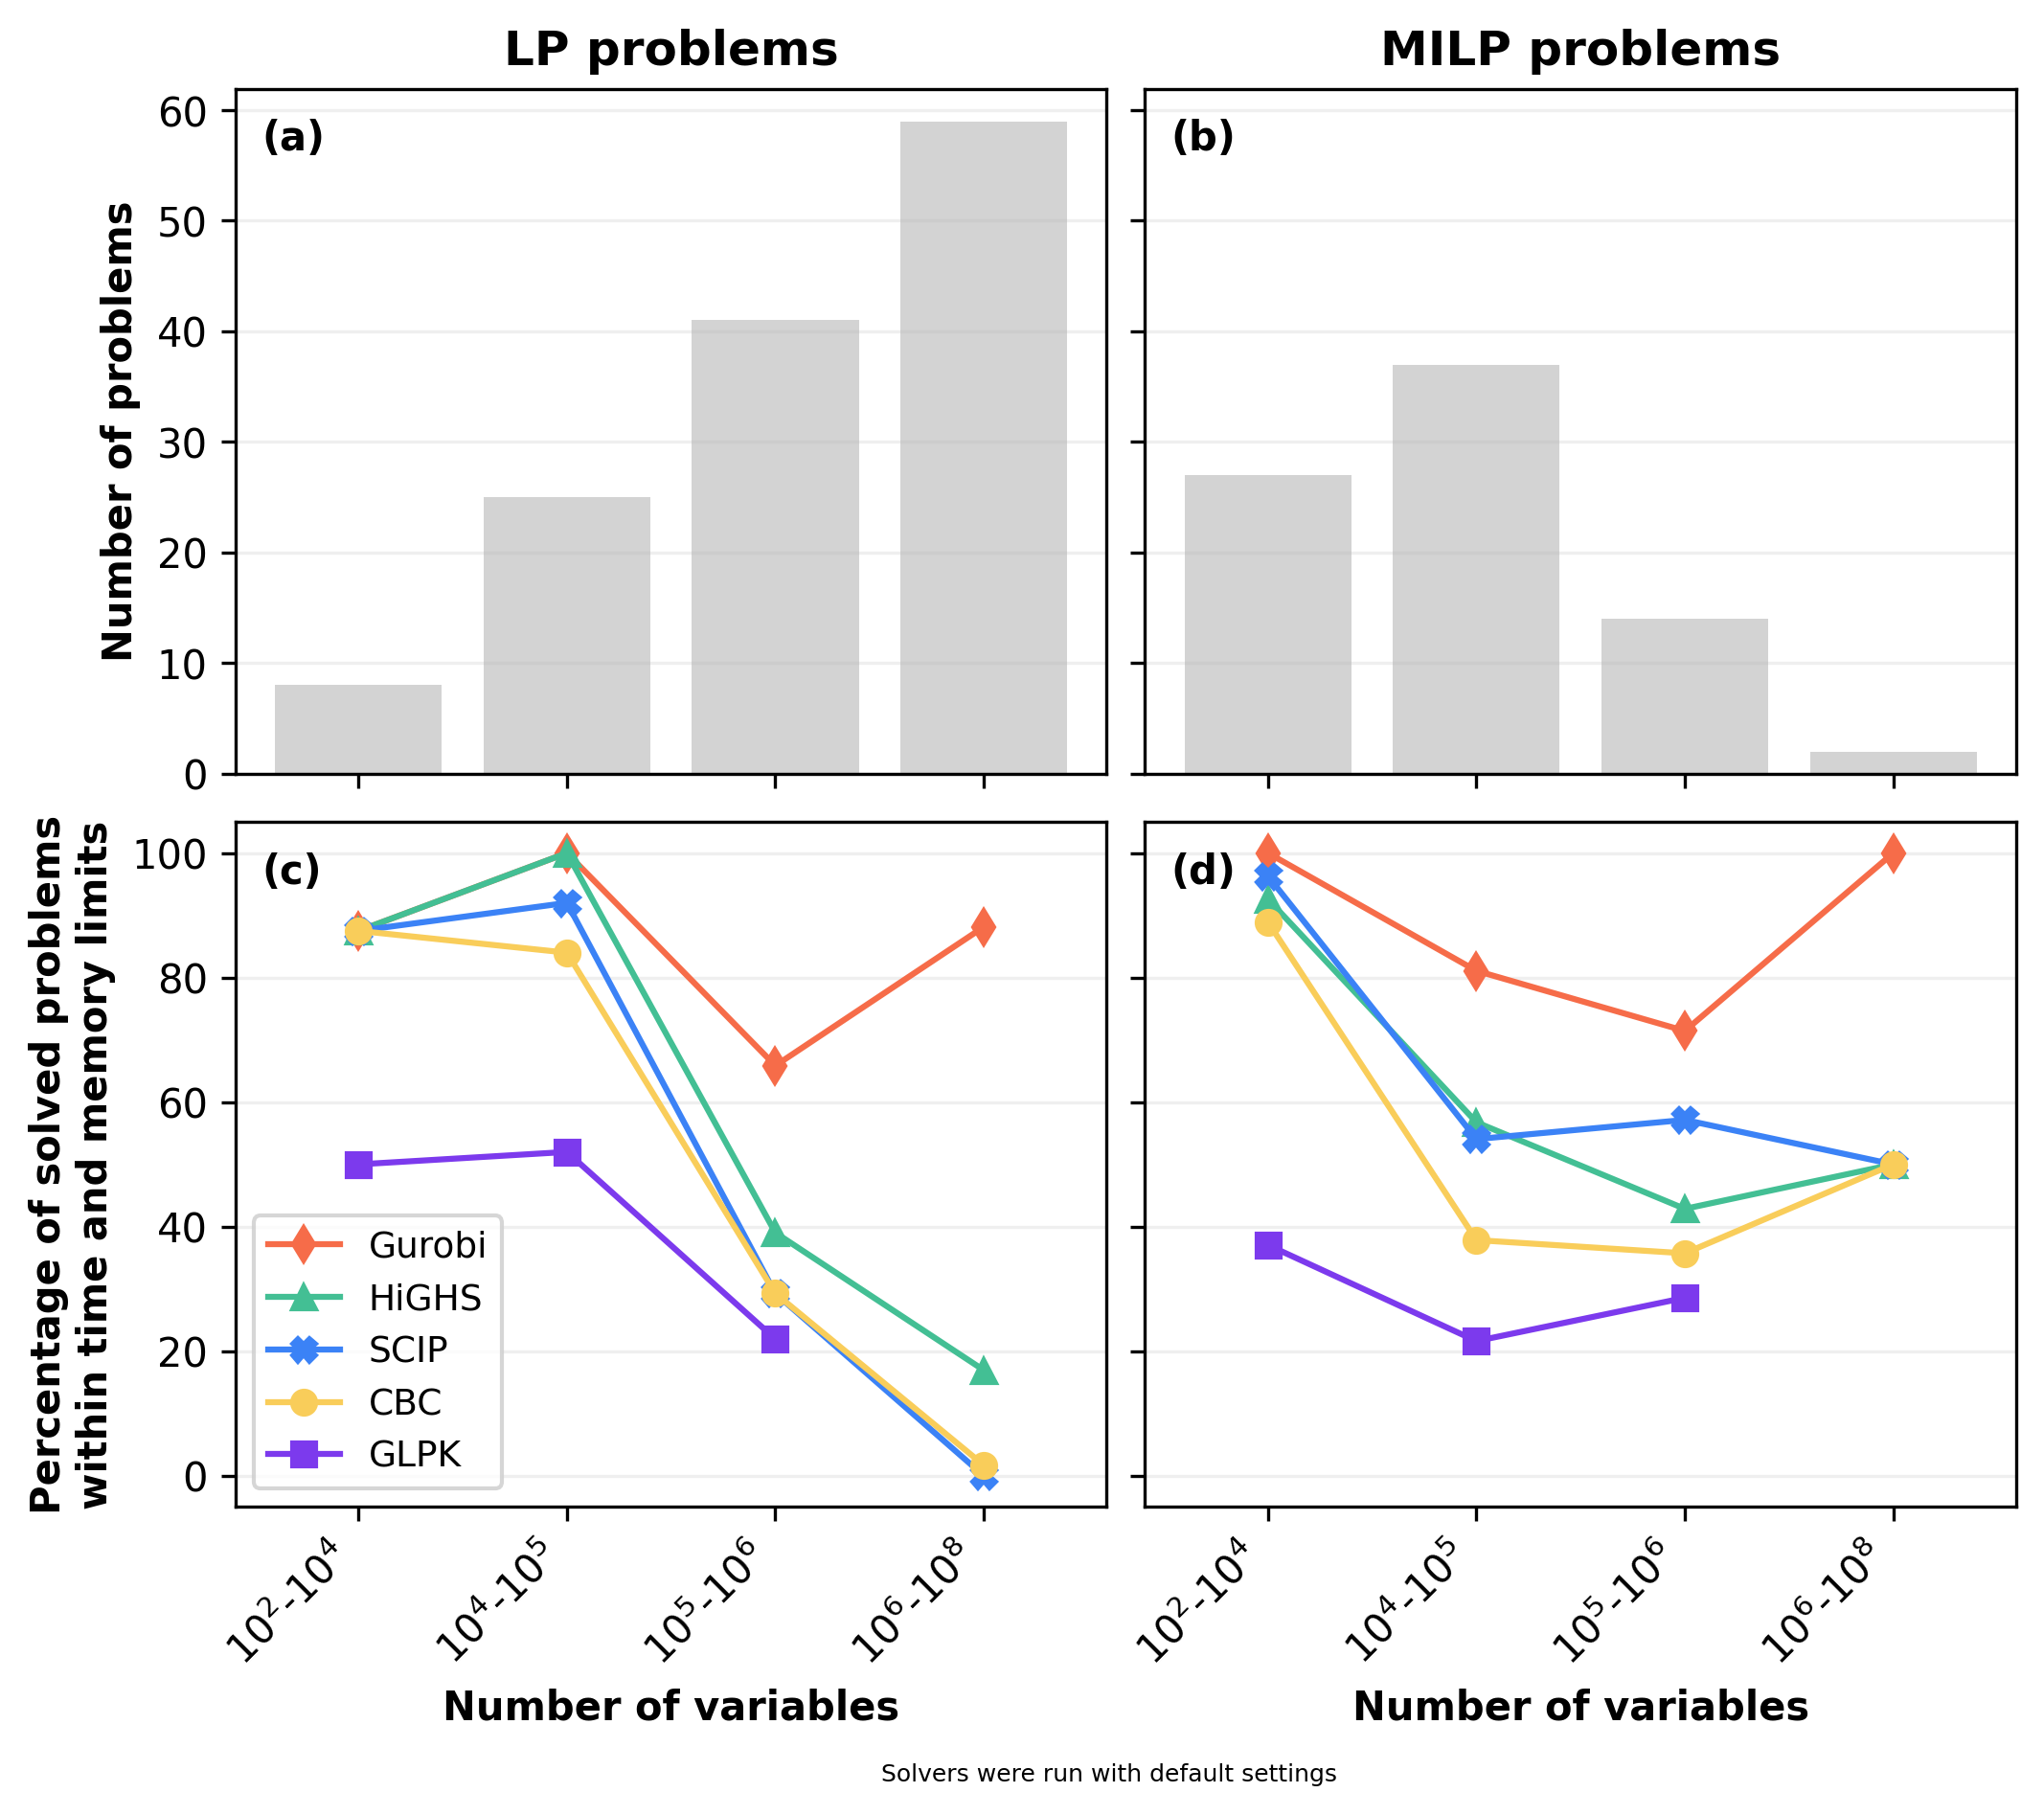

In [20]:
# Initialize the figure and axes for the plot.
fig, axs = matplotlib.pyplot.subplots(
    2, 2, figsize=(7, 6), dpi=300, sharex="col", sharey="row", constrained_layout=True
)

# Add a bar plot for the number of LP problems in each bucket.
axs[0, 0].bar(
    range(len(buckets["LP"])),
    list(num_problems_per_bucket["LP"].values())[0],
    color="lightgrey",
    label="Number of problems",
)
axs[0, 0].set_ylabel("Number of problems", weight="bold")
axs[0, 0].grid(axis="y", alpha=0.2)

# Add the problem type as the title of the first row.
axs[0, 0].set_title("LP problems", weight="bold")

# Add the panel letter.
axs[0, 0].text(
    0.03, 0.91, "(a)", transform=axs[0, 0].transAxes, fontsize=10, weight="bold"
)

# Add a bar plot for the number of MILP problems in each bucket.
axs[0, 1].bar(
    range(len(buckets["MILP"])),
    list(num_problems_per_bucket["MILP"].values())[0],
    color="lightgrey",
    label="Number of problems",
)
axs[0, 1].grid(axis="y", alpha=0.2)

# Add the problem type as the title of the second row.
axs[0, 1].set_title("MILP problems", weight="bold")

# Add the panel letter.
axs[0, 1].text(
    0.03, 0.91, "(b)", transform=axs[0, 1].transAxes, fontsize=10, weight="bold"
)

# Add a line plot for the percentage of LP problems solved in each bucket.
for i, (solver, stats) in enumerate(bucket_stats["LP"]["fraction_solved"].items()):
    buckets_list = stats.keys()
    values = numpy.array(list(stats.values())) * 100
    axs[1, 0].plot(
        range(len(buckets_list)),
        values,
        marker=marker_map.get(solver, None),
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[1, 0].set_ylabel(
    "Percentage of solved problems\nwithin time and memory limits", weight="bold"
)
axs[1, 0].set_xticks(
    range(len(buckets["LP"])),
    labels=list(buckets["LP"].keys()),
    rotation=45,
    ha="right",
)
axs[1, 0].set_xlabel("Number of variables", weight="bold")
axs[1, 0].grid(axis="y", alpha=0.2)
axs[1, 0].legend(loc="lower left", fontsize=9)

# Add the panel letter.
axs[1, 0].text(
    0.03, 0.91, "(c)", transform=axs[1, 0].transAxes, fontsize=10, weight="bold"
)

# Add a line plot for the percentage of MILP problems solved in each bucket.
for i, (solver, stats) in enumerate(bucket_stats["MILP"]["fraction_solved"].items()):
    buckets_list = stats.keys()
    values = numpy.array(list(stats.values())) * 100
    axs[1, 1].plot(
        range(len(buckets_list)),
        values,
        marker=marker_map.get(solver, None),
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[1, 1].set_xticks(
    range(len(buckets["MILP"])),
    labels=list(buckets["MILP"].keys()),
    rotation=45,
    ha="right",
)
axs[1, 1].set_xlabel("Number of variables", weight="bold")
axs[1, 1].grid(axis="y", alpha=0.2)

# Add the panel letter.
axs[1, 1].text(
    0.03, 0.91, "(d)", transform=axs[1, 1].transAxes, fontsize=10, weight="bold"
)

# Add a note saying that solvers were run with default settings.
fig.text(
    0.43,
    -0.02,
    "Solvers were run with default settings",
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

# Save the figure.
fig.savefig(
    "figures/state_of_solvers__fraction_solved_by_problem_size.png",
    bbox_inches="tight",
    dpi=300,
)

# Plot the SGM of the runtime by solver, problem class, and problem size

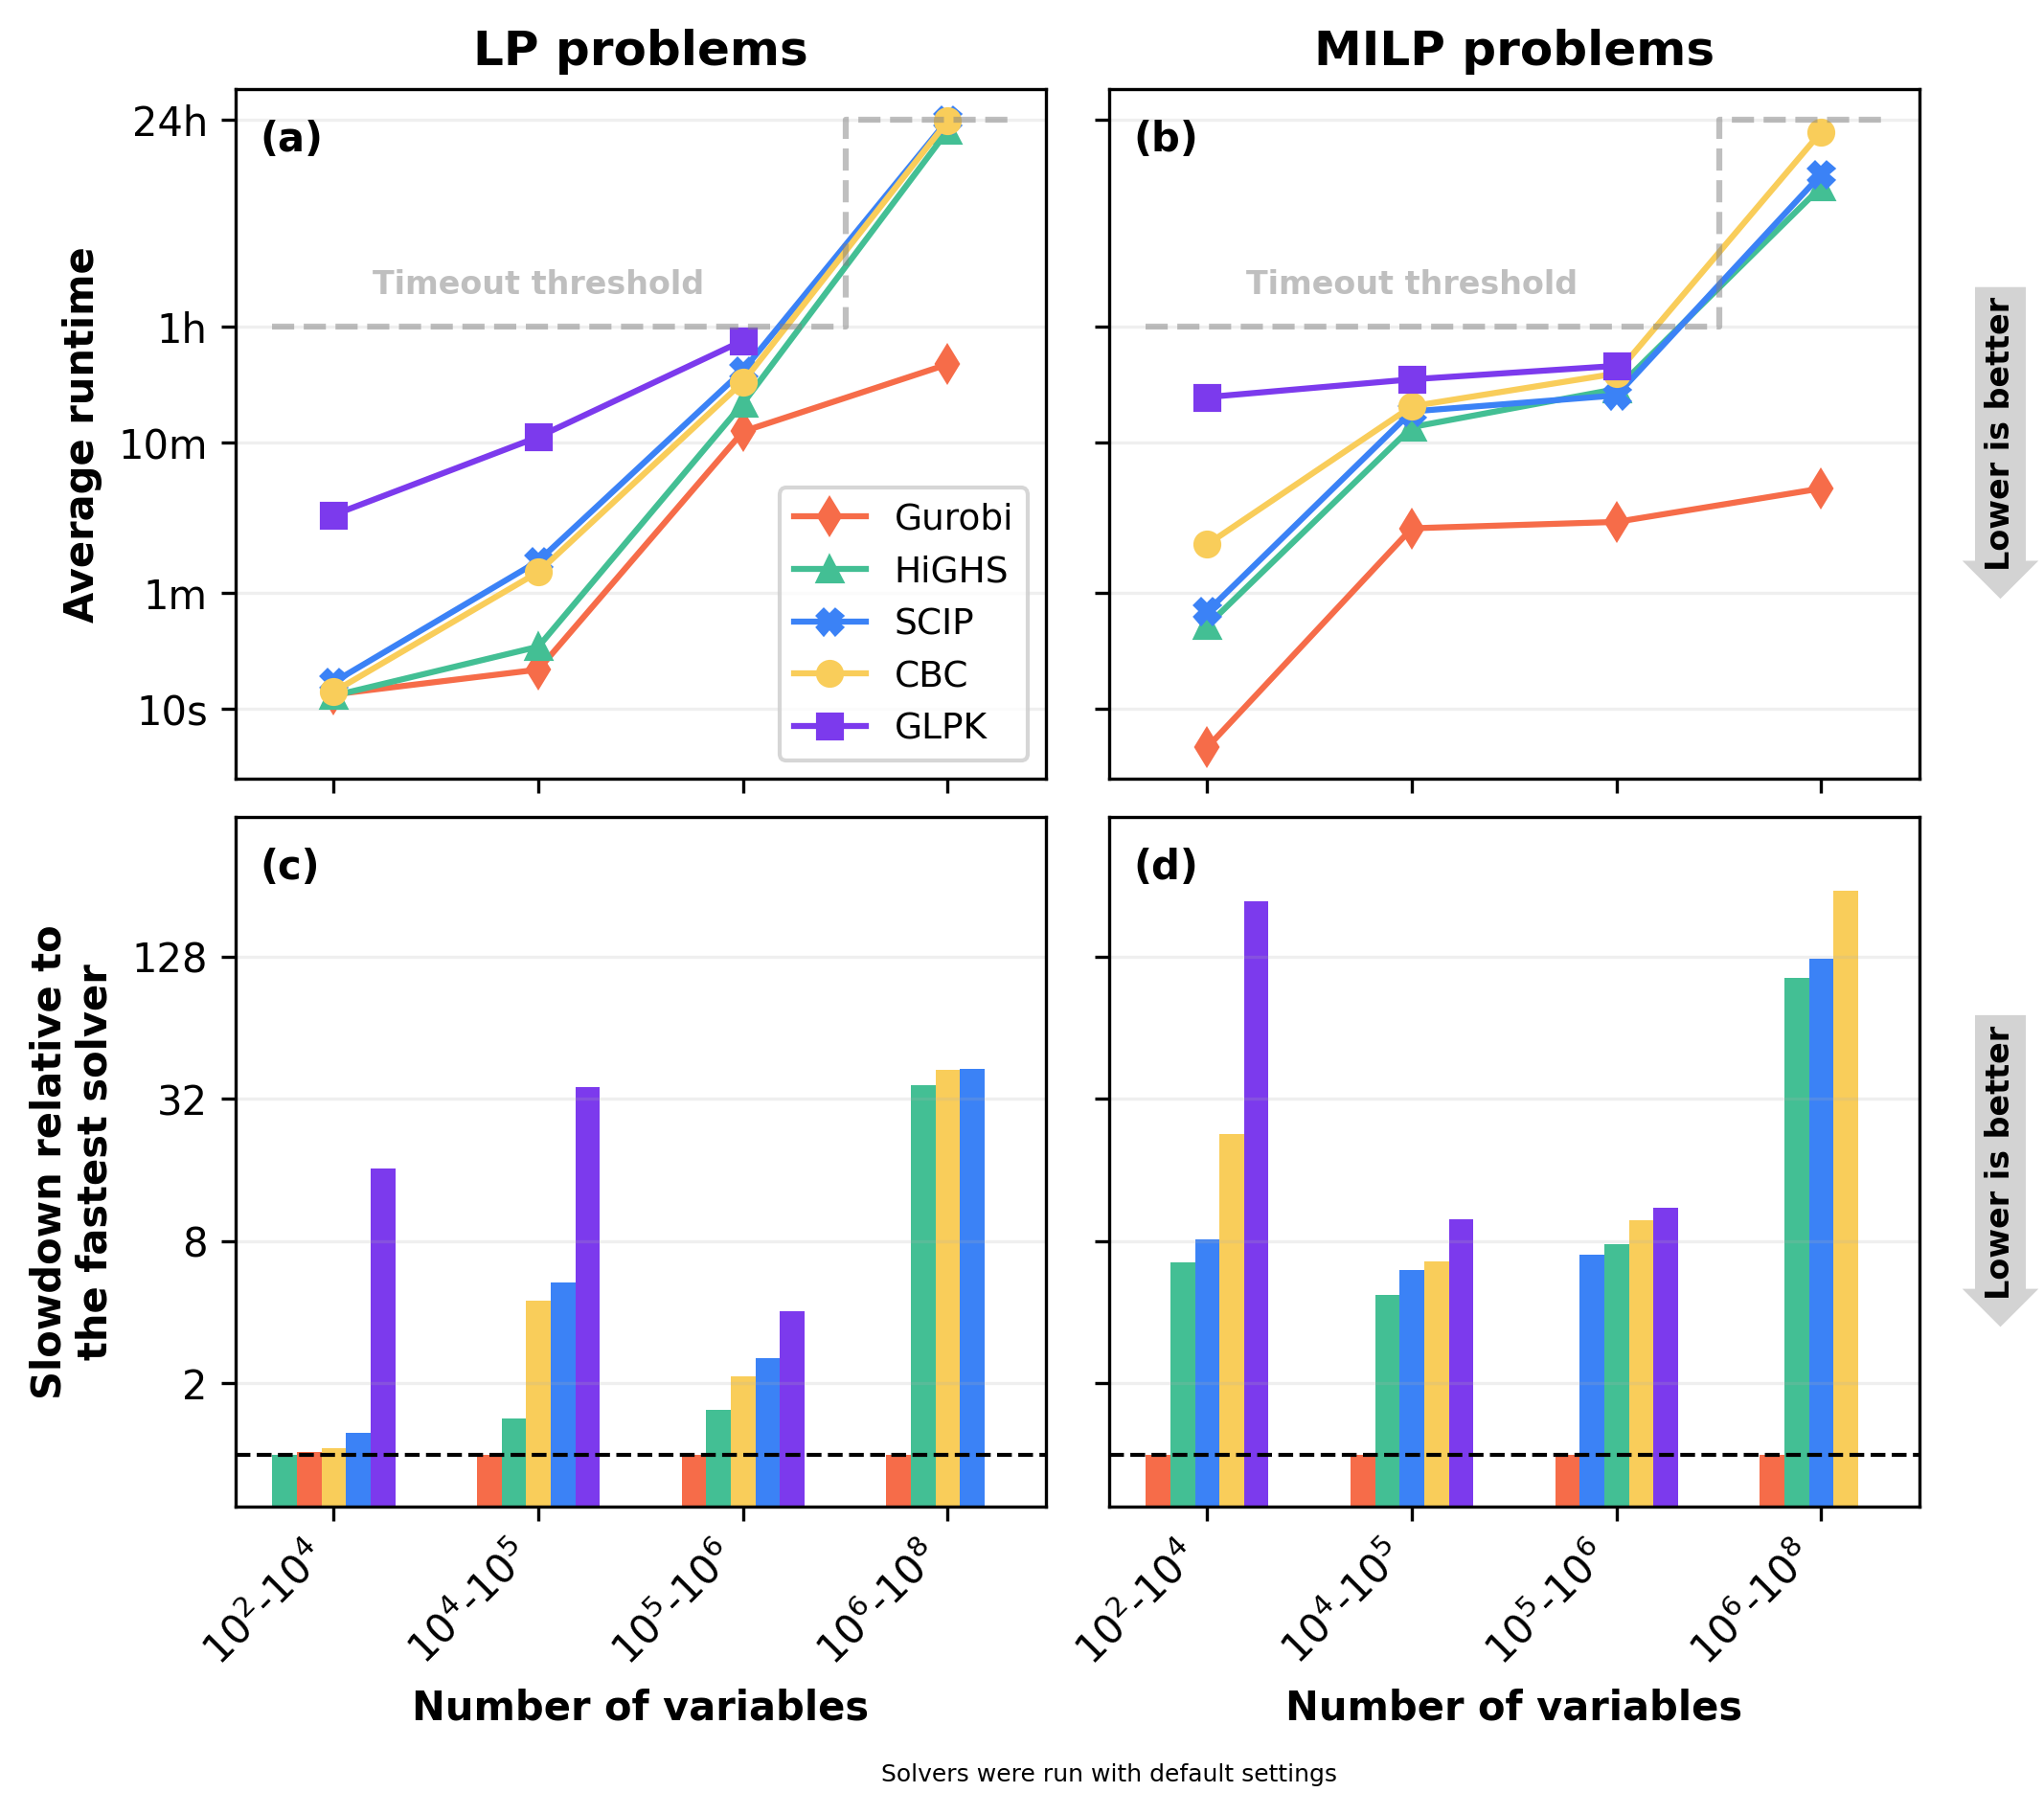

In [21]:
# Initialize the figure and axes for the plot.
fig, axs = matplotlib.pyplot.subplots(
    2, 2, figsize=(7, 6), dpi=300, sharex="col", sharey="row", constrained_layout=True
)

# Add a line plot for the SGM runtime of LP problems in each bucket.
for i, (solver, stats) in enumerate(bucket_stats["LP"]["sgm_runtime"].items()):
    buckets_list = list(stats.keys())
    values = list(stats.values())
    axs[0, 0].plot(
        range(len(buckets_list)),
        values,
        marker=marker_map.get(solver, None),
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[0, 0].set_yscale("log")
axs[0, 0].minorticks_off()
axs[0, 0].set_ylabel("Average runtime", weight="bold")
axs[0, 0].set_yticks(
    [0.01, 0.1, 1, 10, 60, 600, 3600, 86400],
    ["0.01s", "0.1s", "1s", "10s", "1m", "10m", "1h", "24h"],
)
axs[0, 0].grid(axis="y", alpha=0.2)
axs[0, 0].legend(loc="lower right", fontsize=9)

# Add a dashed line to indicate the timeout threshold.
axs[0, 0].plot(
    [-0.3, 2.5, 2.5, 3.3],
    [3600, 3600, 24 * 3600, 24 * 3600],
    linestyle="--",
    alpha=0.5,
    color="grey",
)
axs[0, 0].text(
    1,
    3600 * 1.5,
    "Timeout threshold",
    ha="center",
    va="bottom",
    fontsize=8,
    alpha=0.5,
    color="grey",
    weight="bold",
)

# Add the problem type as the title of the first row.
axs[0, 0].set_title("LP problems", weight="bold")

# Add the panel letter.
axs[0, 0].text(
    0.03, 0.91, "(a)", transform=axs[0, 0].transAxes, fontsize=10, weight="bold"
)

# Add a line plot for the SGM runtime of MILP problems in each bucket.
for i, (solver, stats) in enumerate(bucket_stats["MILP"]["sgm_runtime"].items()):
    buckets_list = list(stats.keys())
    values = list(stats.values())
    axs[0, 1].plot(
        range(len(buckets_list)),
        values,
        marker=marker_map.get(solver, None),
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[0, 1].grid(axis="y", alpha=0.2)
axs[0, 1].text(
    1.1,
    0.5,
    "Lower is better",
    transform=axs[0, 1].transAxes,
    ha="center",
    va="center",
    weight="bold",
    fontsize=8,
    rotation=90,
    bbox=dict(boxstyle="larrow", facecolor="lightgrey", edgecolor="none"),
)

# Add a dashed line to indicate the timeout threshold.
axs[0, 1].plot(
    [-0.3, 2.5, 2.5, 3.3],
    [3600, 3600, 24 * 3600, 24 * 3600],
    linestyle="--",
    alpha=0.5,
    color="grey",
)
axs[0, 1].text(
    1,
    3600 * 1.5,
    "Timeout threshold",
    ha="center",
    va="bottom",
    fontsize=8,
    alpha=0.5,
    color="grey",
    weight="bold",
)

# Add the problem type as the title of the second row.
axs[0, 1].set_title("MILP problems", weight="bold")

# Add the panel letter.
axs[0, 1].text(
    0.03, 0.91, "(b)", transform=axs[0, 1].transAxes, fontsize=10, weight="bold"
)

# Add a bar plot for the relative SGM runtime in each bucket.
for solver in all_results["Solver"].unique():
    buckets_list = list(bucket_stats["LP"]["relative_sgm_runtime"][solver].keys())
    values = list(bucket_stats["LP"]["relative_sgm_runtime"][solver].values())
    positions = [
        j + -0.24 + 0.12 * (rank - 1)
        for j, rank in enumerate(
            bucket_stats["LP"]["relative_sgm_runtime_rank"][solver].values()
        )
    ]
    axs[1, 0].bar(
        positions,
        values,
        width=0.12,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[1, 0].axhline(1, color="black", linestyle="--", linewidth=1)
axs[1, 0].set_yscale("log", base=2)
axs[1, 0].set_ylim(0.6, 500)
axs[1, 0].set_yticks([2, 8, 32, 128], ["2", "8", "32", "128"])
axs[1, 0].minorticks_off()
axs[1, 0].set_ylabel("Slowdown relative to\nthe fastest solver", weight="bold")
axs[1, 0].set_xticks(range(len(buckets_list)), buckets_list, rotation=45, ha="right")
axs[1, 0].set_xlabel("Number of variables", weight="bold")
axs[1, 0].grid(axis="y", alpha=0.2)

# Add the panel letter.
axs[1, 0].text(
    0.03, 0.91, "(c)", transform=axs[1, 0].transAxes, fontsize=10, weight="bold"
)

# Add a bar plot for the relative SGM runtime in each bucket.
for solver in all_results["Solver"].unique():
    buckets_list = list(bucket_stats["MILP"]["relative_sgm_runtime"][solver].keys())
    values = list(bucket_stats["MILP"]["relative_sgm_runtime"][solver].values())
    positions = [
        j + -0.24 + 0.12 * (rank - 1)
        for j, rank in enumerate(
            bucket_stats["MILP"]["relative_sgm_runtime_rank"][solver].values()
        )
    ]
    axs[1, 1].bar(
        positions,
        values,
        width=0.12,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[1, 1].axhline(1, color="black", linestyle="--", linewidth=1)
axs[1, 1].set_xticks(range(len(buckets_list)), buckets_list, rotation=45, ha="right")
axs[1, 1].set_xlabel("Number of variables", weight="bold")
axs[1, 1].grid(axis="y", alpha=0.2)
axs[1, 1].text(
    1.1,
    0.5,
    "Lower is better",
    transform=axs[1, 1].transAxes,
    ha="center",
    va="center",
    weight="bold",
    fontsize=8,
    rotation=90,
    bbox=dict(boxstyle="larrow", facecolor="lightgrey", edgecolor="none"),
)

# Add the panel letter.
axs[1, 1].text(
    0.03, 0.91, "(d)", transform=axs[1, 1].transAxes, fontsize=10, weight="bold"
)

# Add a note saying that solvers were run with default settings.
fig.text(
    0.43,
    -0.02,
    "Solvers were run with default settings",
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

# Save the figure.
fig.savefig(
    "figures/state_of_solvers__sgm_runtime_by_problem_size.png",
    bbox_inches="tight",
    dpi=300,
)

# Plot the results by modelling framework.

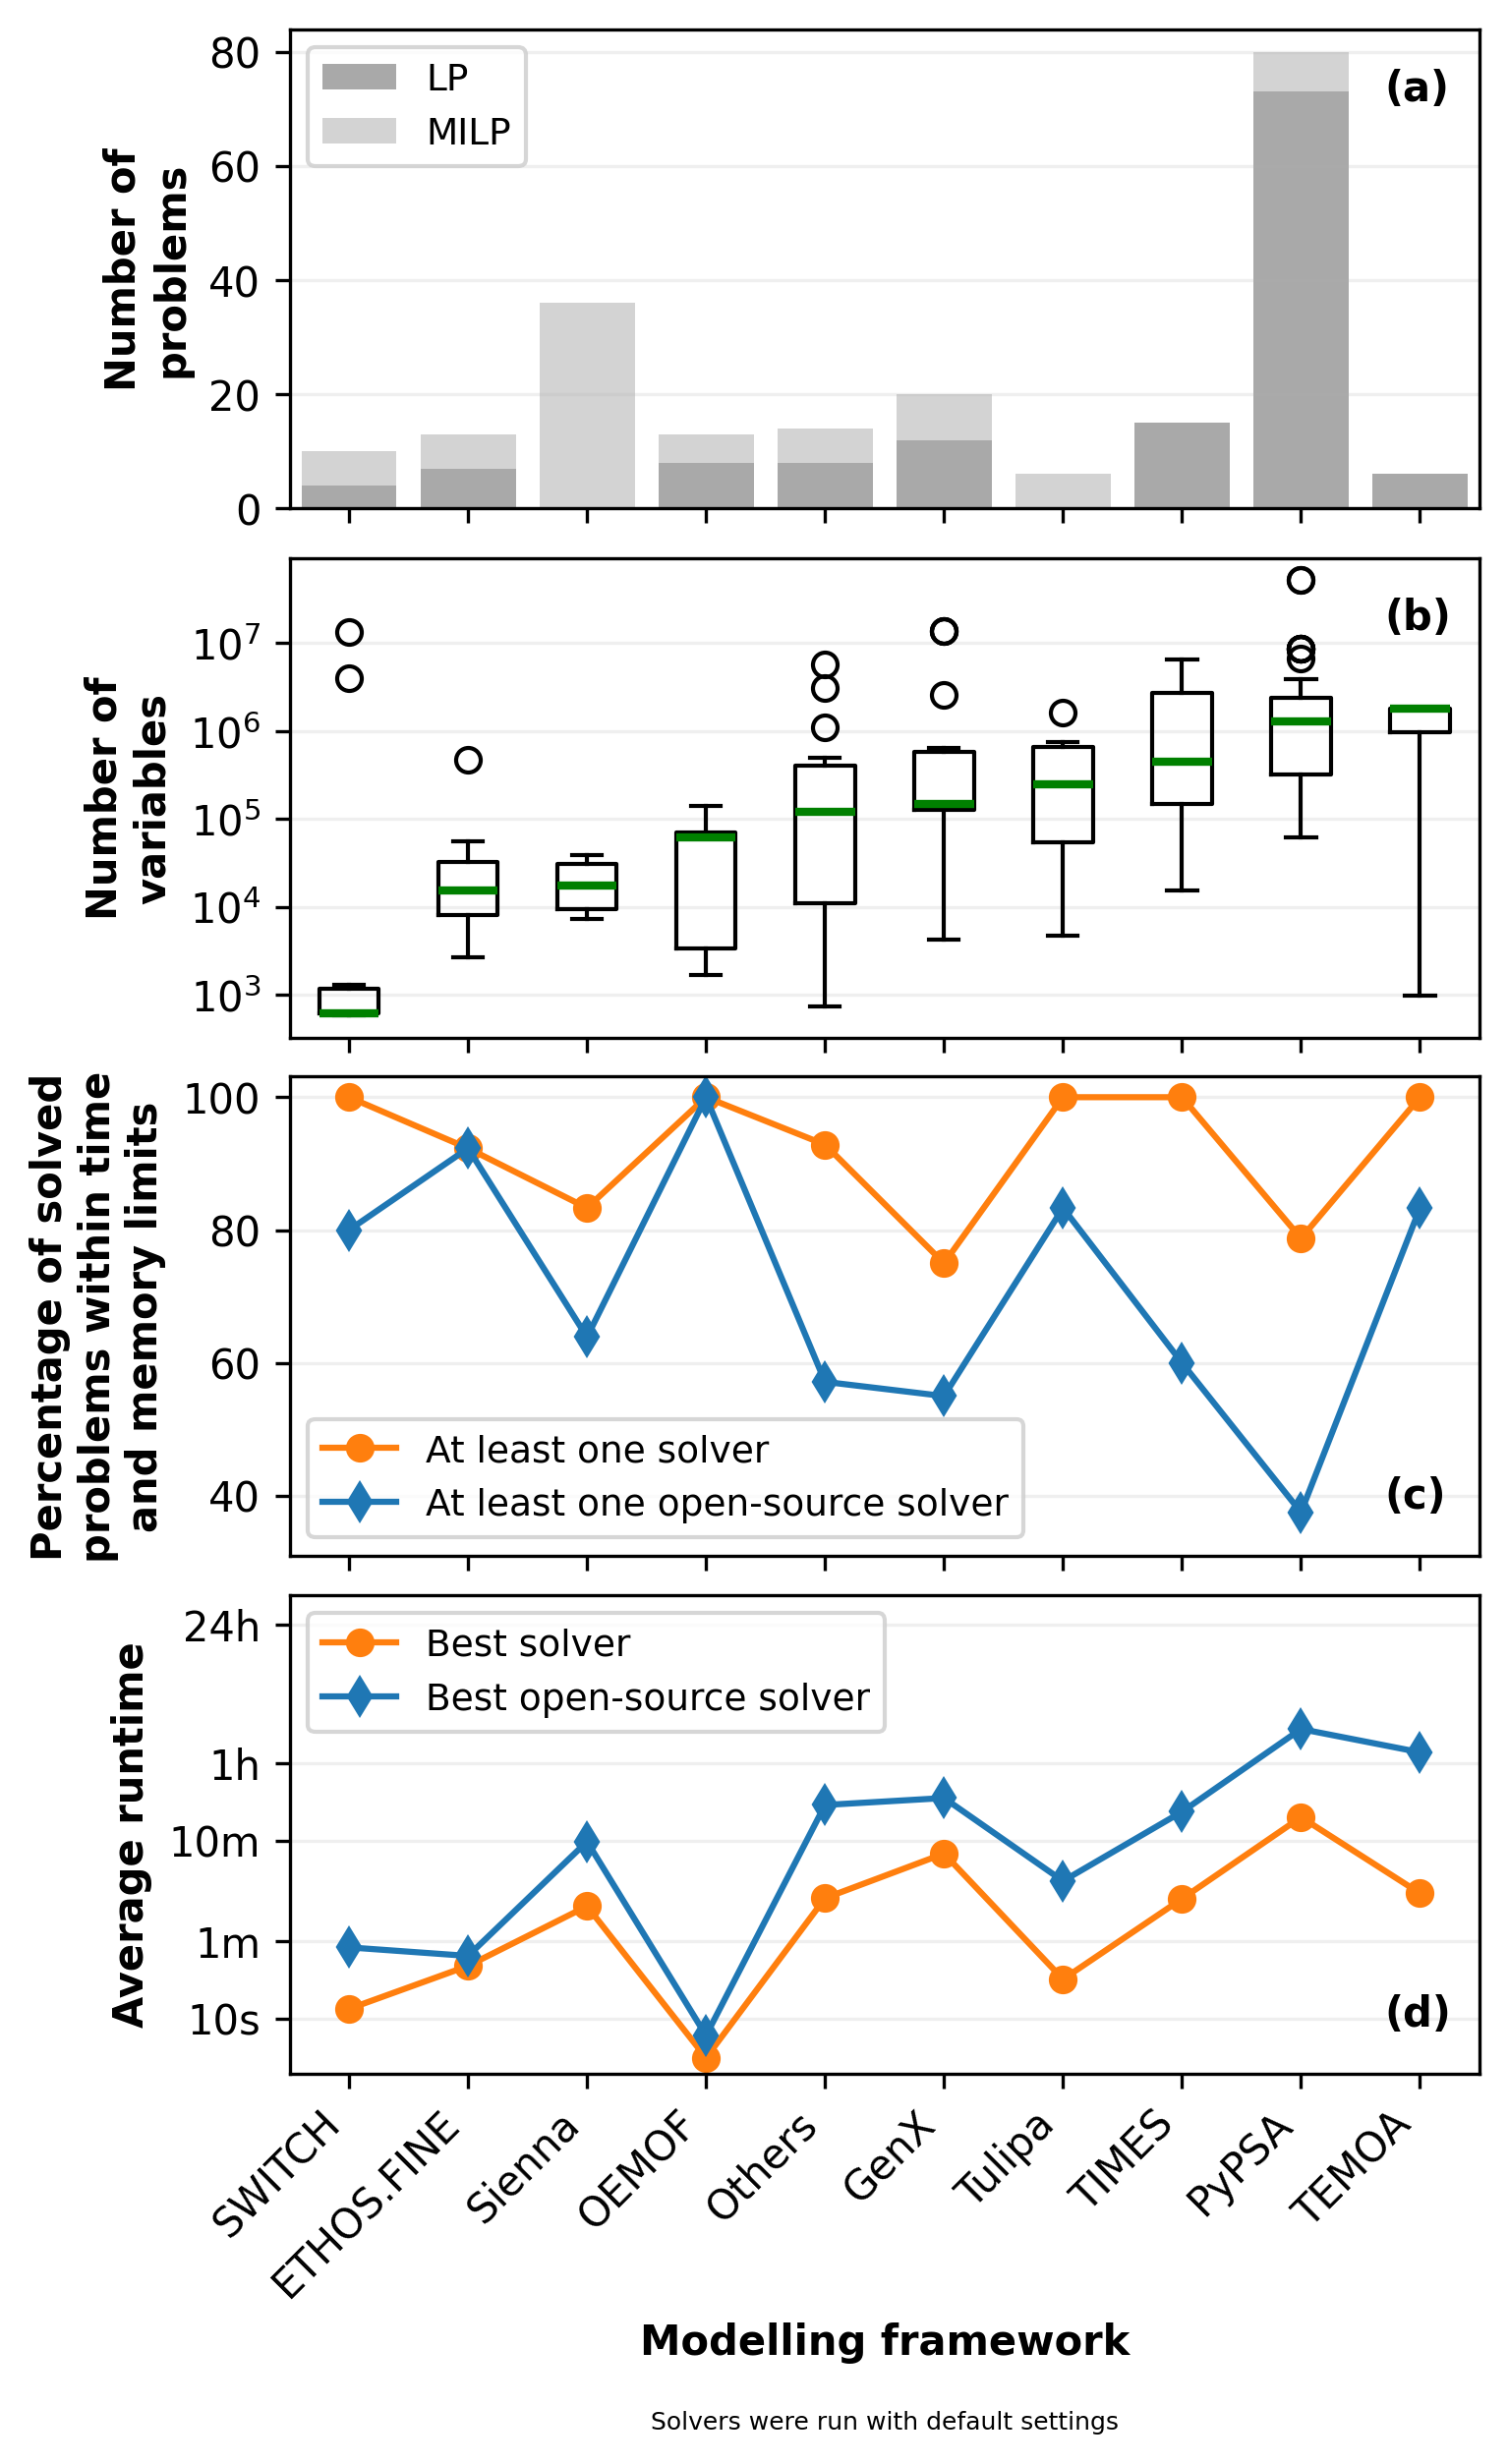

In [22]:
# Initialize the figure and axes for the plot.
fig, axs = matplotlib.pyplot.subplots(
    4, 1, figsize=(5, 8), dpi=300, sharex=True, constrained_layout=True
)

# Add a bar plot for the number of problems in each modelling framework.
axs[0].bar(
    model_framework_stats["num_lp_problems"].keys(),
    model_framework_stats["num_lp_problems"].values(),
    color="darkgrey",
    label="LP",
)
axs[0].bar(
    model_framework_stats["num_milp_problems"].keys(),
    model_framework_stats["num_milp_problems"].values(),
    color="lightgrey",
    label="MILP",
    bottom=list(model_framework_stats["num_lp_problems"].values()),
)
axs[0].set_ylabel("Number of\nproblems", weight="bold")
axs[0].grid(axis="y", alpha=0.2)
axs[0].legend(loc="upper left", fontsize=9)

# Add the panel letter.
axs[0].text(0.92, 0.85, "(a)", transform=axs[0].transAxes, fontsize=10, weight="bold")

# Add a box and whisker plot for the number of variables in each modelling framework.
axs[1].boxplot(
    model_framework_stats["number_of_variables"].values(),
    positions=range(len(model_framework_stats["number_of_variables"].keys())),
    medianprops=dict(color="green", linewidth=2),
)
axs[1].set_ylabel("Number of\nvariables", weight="bold")
axs[1].set_yscale("log")
axs[1].minorticks_off()
axs[1].grid(axis="y", alpha=0.2)

# Add the panel letter.
axs[1].text(0.92, 0.85, "(b)", transform=axs[1].transAxes, fontsize=10, weight="bold")

# Add a line plot for the fraction of problems solved in each modelling framework.
axs[2].plot(
    model_framework_stats["fraction_solved_by_any_solver"].keys(),
    numpy.array(list(model_framework_stats["fraction_solved_by_any_solver"].values()))
    * 100,
    marker="o",
    label="At least one solver",
    color="tab:orange",
)
axs[2].plot(
    model_framework_stats["fraction_solved_by_any_open_source_solver"].keys(),
    numpy.array(
        list(
            model_framework_stats["fraction_solved_by_any_open_source_solver"].values()
        )
    )
    * 100,
    marker="d",
    label="At least one open-source solver",
    color="tab:blue",
)
axs[2].set_ylabel(
    "Percentage of solved\nproblems within time\nand memory limits", weight="bold"
)
axs[2].grid(axis="y", alpha=0.2)
axs[2].legend(loc="lower left", fontsize=9)
y_lims = axs[2].get_ylim()
axs[2].set_ylim(y_lims[0] * 0.9, y_lims[1])

# Add the panel letter.
axs[2].text(0.92, 0.1, "(c)", transform=axs[2].transAxes, fontsize=10, weight="bold")

# Add a line plot for the SGM runtime in each modelling framework.
axs[3].plot(
    model_framework_stats["sgm_runtime_of_best_solver"].keys(),
    list(model_framework_stats["sgm_runtime_of_best_solver"].values()),
    marker="o",
    label="Best solver",
    color="tab:orange",
    zorder=2,
)
axs[3].plot(
    model_framework_stats["sgm_runtime_of_best_open_source_solver"].keys(),
    list(model_framework_stats["sgm_runtime_of_best_open_source_solver"].values()),
    marker="d",
    label="Best open-source solver",
    color="tab:blue",
    zorder=2,
)
axs[3].set_yscale("log")
axs[3].minorticks_off()
axs[3].set_ylabel("Average runtime", weight="bold")
axs[3].set_yticks(
    [10, 60, 600, 3600, 86400],
    ["10s", "1m", "10m", "1h", "24h"],
)
axs[3].set_ylim(top=2 * 86400)
axs[3].grid(axis="y", alpha=0.2)
axs[3].set_xticks(
    range(len(model_framework_stats["num_lp_problems"].keys())),
    model_framework_stats["num_lp_problems"].keys(),
    rotation=45,
    ha="right",
)
axs[3].set_xlabel("Modelling framework", weight="bold")
axs[3].legend(loc="upper left", fontsize=9)

# Add the panel letter.
axs[3].text(0.92, 0.1, "(d)", transform=axs[3].transAxes, fontsize=10, weight="bold")

# Add a note saying that solvers were run with default settings.
fig.text(
    0.43,
    -0.02,
    "Solvers were run with default settings",
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

# Save the figure.
fig.savefig(
    "figures/state_of_solvers__performance_by_modelling_framework.png",
    bbox_inches="tight",
    dpi=300,
)

# Plot the solver performance evolution over time

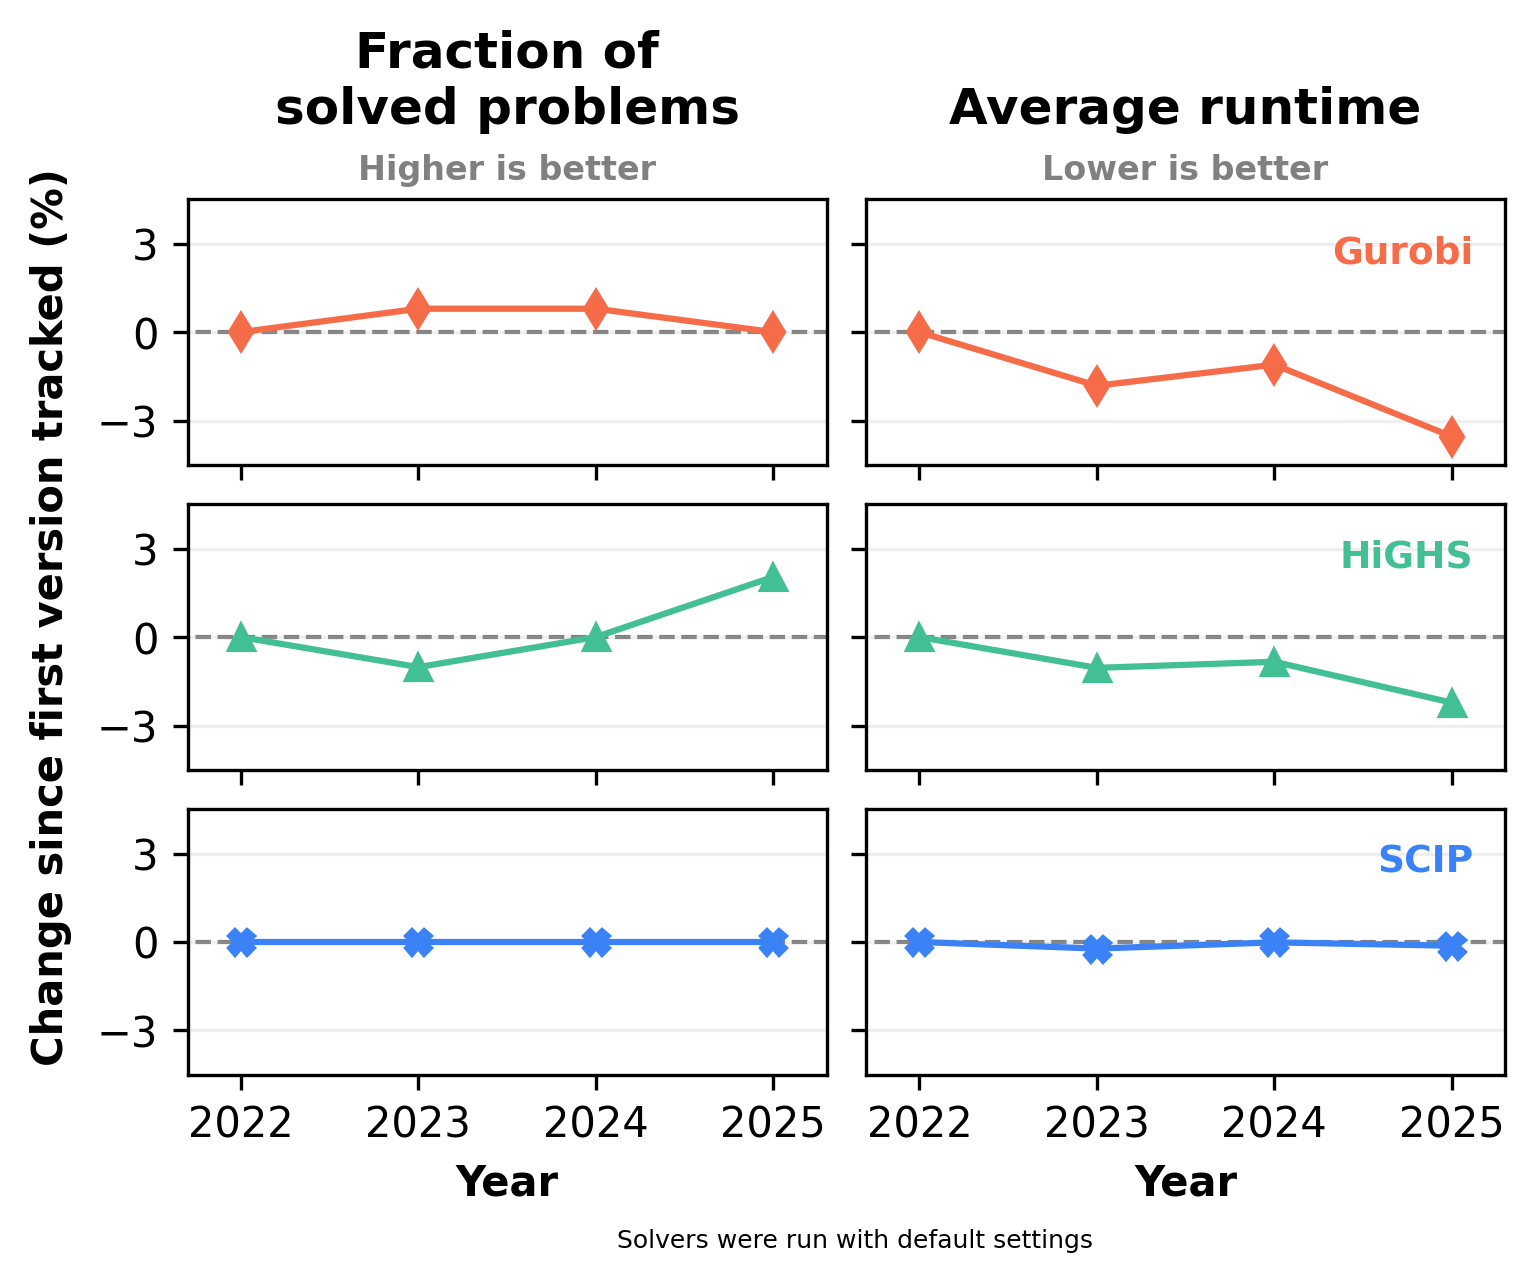

In [23]:
# Initialize the figure and axes for the plot.
fig, axs = matplotlib.pyplot.subplots(
    3, 2, figsize=(5, 4), dpi=300, sharex=True, sharey=True, constrained_layout=True
)

solvers_to_plot = ["gurobi", "highs", "scip"]

# Add a line plot for the fraction of solved problems over time for each solver.
for i, solver in enumerate(solvers_to_plot):
    solver_data = performance_evolution.xs(solver, level="solver")
    axs[i, 0].plot(
        solver_data.index.get_level_values("release_year"),
        (solver_data["fraction_solved"] / solver_data["fraction_solved"].iloc[0] - 1)
        * 100,
        marker=marker_map.get(solver, None),
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
    axs[i, 0].set_ylim(-4.5, 4.5)
    axs[i, 0].set_yticks([-3, 0, 3])
    axs[i, 0].hlines(
        0, 2021, 2026, color="black", linestyle="--", linewidth=1, zorder=0, alpha=0.5
    )
    axs[i, 0].set_xlim(2021.7, 2025.3)
    axs[i, 0].grid(axis="y", alpha=0.2)

# Add the variable shown as the title of the first row.
axs[0, 0].text(
    0.5,
    1.25,
    "Fraction of\nsolved problems",
    transform=axs[0, 0].transAxes,
    weight="bold",
    fontsize=12,
    ha="center",
    va="bottom",
    clip_on=False,
)
axs[0, 0].text(
    0.5,
    1.05,
    "Higher is better",
    transform=axs[0, 0].transAxes,
    ha="center",
    va="bottom",
    weight="bold",
    fontsize=8,
    color="grey",
    clip_on=False,
)
axs[0, 1].text(
    0.5,
    1.25,
    "Average runtime",
    transform=axs[0, 1].transAxes,
    weight="bold",
    fontsize=12,
    ha="center",
    va="bottom",
    clip_on=False,
)
axs[0, 1].text(
    0.5,
    1.05,
    "Lower is better",
    transform=axs[0, 1].transAxes,
    ha="center",
    va="bottom",
    weight="bold",
    fontsize=8,
    color="grey",
    clip_on=False,
)

# Add the x-axis label to the last row.
axs[2, 0].set_xlabel("Year", weight="bold")
axs[2, 1].set_xlabel("Year", weight="bold")

# Add a line plot for the SGM runtime over time for each solver.
for i, solver in enumerate(solvers_to_plot):
    solver_data = performance_evolution.xs(solver, level="solver")
    axs[i, 1].plot(
        solver_data.index.get_level_values("release_year"),
        (solver_data["sgm_runtime"] / solver_data["sgm_runtime"].iloc[0] - 1) * 100,
        marker=marker_map.get(solver, None),
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
    axs[i, 1].hlines(
        0, 2021, 2026, color="black", linestyle="--", linewidth=1, zorder=0, alpha=0.5
    )
    axs[i, 1].set_xlim(2021.7, 2025.3)
    axs[i, 1].grid(axis="y", alpha=0.2)

# Add the solver name as the title of each row.
for i, solver in enumerate(solvers_to_plot):
    axs[i, 1].text(
        0.95,
        0.8,
        name_map.get(solver, solver),
        transform=axs[i, 1].transAxes,
        ha="right",
        va="center",
        weight="bold",
        color=color_map.get(solver, None),
        fontsize=9,
    )

# Add a common y label.
fig.supylabel("Change since first version tracked (%)", weight="bold", fontsize=10)

# Add a note saying that solvers were run with default settings.
fig.text(
    0.40,
    -0.02,
    "Solvers were run with default settings",
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

# Save the figure.
fig.savefig(
    "figures/state_of_solvers__performance_evolution_over_time.png",
    bbox_inches="tight",
    dpi=300,
)

# Plot the number of non-zeros and constraints as a function of the number of variables

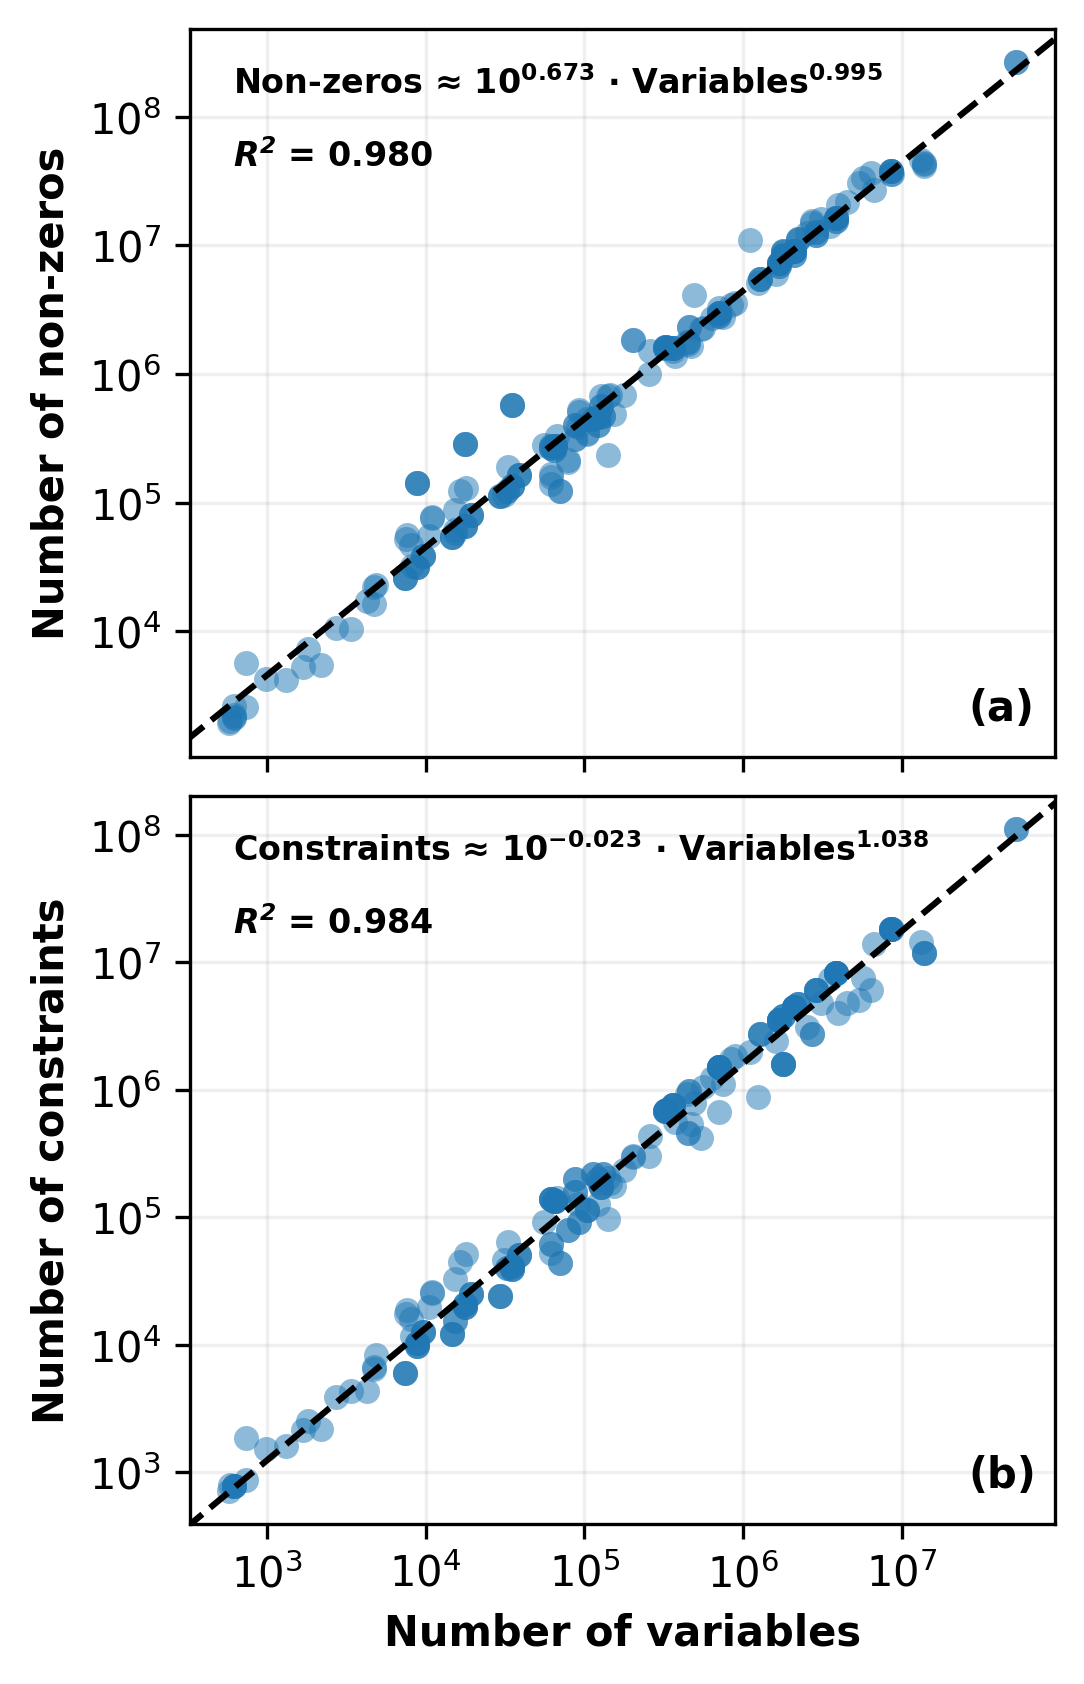

In [24]:
# Initialize the figure and axes for the plot.
fig, axs = matplotlib.pyplot.subplots(
    2, 1, figsize=(3.5, 5.5), dpi=300, sharex=True, constrained_layout=True
)

# Add a scatter plot for the number of variables vs the number of non-zeros.
axs[0].plot(
    latest_solver_results.groupby("bench-size")["Variables"].mean(),
    latest_solver_results.groupby("bench-size")["Non-zeros"].mean(),
    marker="o",
    markeredgecolor="None",
    linestyle="",
    alpha=0.5,
)
axs[0].set_ylabel("Number of non-zeros", weight="bold")
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].minorticks_off()
x_lims = axs[0].get_xlim()
y_lims = axs[0].get_ylim()
axs[0].plot(
    [1e2, 1e9],
    [
        numpy.power(10, intercept_1) * numpy.power(1e2, slope_1),
        numpy.power(10, intercept_1) * numpy.power(1e9, slope_1),
    ],
    color="k",
    linestyle="--",
)
axs[0].set_xlim(x_lims)
axs[0].set_ylim(y_lims)
axs[0].grid(alpha=0.2)

# Add the equation of the fitted line and the R^2 value as text in the plot.
axs[0].text(
    0.05,
    0.95,
    rf"Non-zeros ≈ $\mathbf{{10^{{{intercept_1:.3f}}}}}$ $\mathbf{{\bullet}}$ Variables$\mathbf{{^{{{slope_1:.3f}}}}}$",
    transform=axs[0].transAxes,
    ha="left",
    va="top",
    fontsize=8,
    weight="bold",
)
axs[0].text(
    0.05,
    0.85,
    rf"$\mathbfit{{R^2}}$ = {r_value_1**2:.3f}",
    transform=axs[0].transAxes,
    ha="left",
    va="top",
    fontsize=8,
    weight="bold",
)

# Add the panel letter.
axs[0].text(0.90, 0.05, "(a)", transform=axs[0].transAxes, fontsize=10, weight="bold")

# Add a scatter plot for the number of variables vs the number of constraints.
axs[1].plot(
    latest_solver_results.groupby("bench-size")["Variables"].mean(),
    latest_solver_results.groupby("bench-size")["Constraints"].mean(),
    marker="o",
    markeredgecolor="None",
    linestyle="",
    alpha=0.5,
)
axs[1].set_xlabel("Number of variables", weight="bold")
axs[1].set_ylabel("Number of constraints", weight="bold")
axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].minorticks_off()
axs[1].grid(alpha=0.2)
x_lims = axs[1].get_xlim()
y_lims = axs[1].get_ylim()
axs[1].plot(
    [1e2, 1e9],
    [
        numpy.power(10, intercept_2) * numpy.power(1e2, slope_2),
        numpy.power(10, intercept_2) * numpy.power(1e9, slope_2),
    ],
    color="k",
    linestyle="--",
)
axs[1].set_xlim(x_lims)
axs[1].set_ylim(y_lims)

# Add the equation of the fitted line and the R^2 value as text in the plot.
axs[1].text(
    0.05,
    0.95,
    rf"Constraints ≈ $\mathbf{{10^{{{intercept_2:.3f}}}}}$ $\mathbf{{\bullet}}$ Variables$\mathbf{{^{{{slope_2:.3f}}}}}$",
    transform=axs[1].transAxes,
    ha="left",
    va="top",
    fontsize=8,
    weight="bold",
)
axs[1].text(
    0.05,
    0.85,
    rf"$\mathbfit{{R^2}}$ = {r_value_2**2:.3f}",
    transform=axs[1].transAxes,
    ha="left",
    va="top",
    fontsize=8,
    weight="bold",
)

# Add the panel letter.
axs[1].text(0.90, 0.05, "(b)", transform=axs[1].transAxes, fontsize=10, weight="bold")

fig.savefig(
    "figures/state_of_solvers__problem_size_characteristics.png",
    bbox_inches="tight",
    dpi=300,
)

# Plot the runtime of the PyPSA-DE problems by solver as a function of the spatial and temporal resolution.

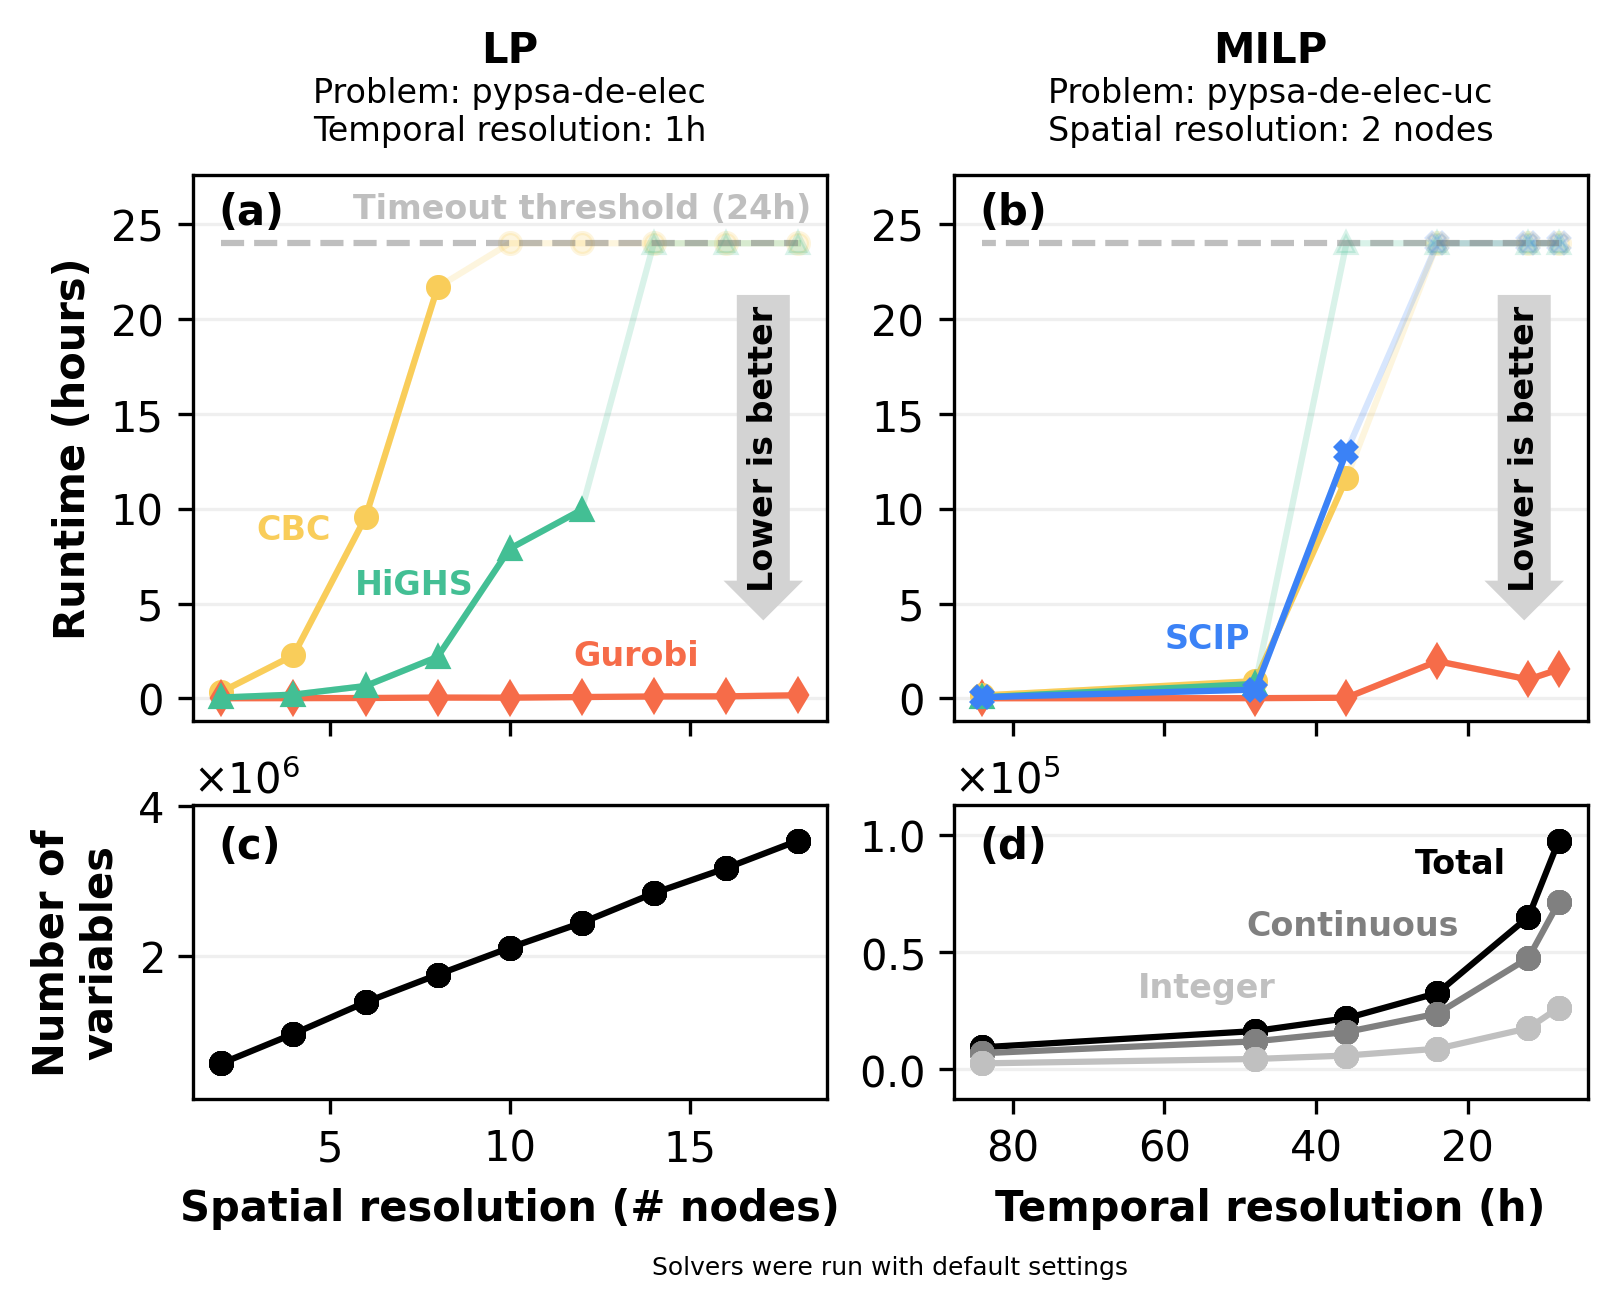

In [25]:
# Define the timeout threshold in hours.
timeout_threshold = 24

# Initialize the figure and axis.
fig, axs = matplotlib.pyplot.subplots(
    2,
    2,
    figsize=(6, 4),
    dpi=300,
    sharex="col",
    gridspec_kw={"height_ratios": [0.65, 0.35]},
)

# Define the x-axis limits based on the spatial and temporal resolution of the benchmark instances.
x_axis_limits_lp = (2, 18)
x_axis_limits_milp = (8, 84)

# Add a line plot for the runtime of LP problems.
for solver in ["cbc", "gurobi", "highs", "scip"]:
    # Get the results for the current solver.
    solver_results = pypsa_de_elec_results[
        pypsa_de_elec_results["Solver"] == solver
    ].copy()

    # Convert from seconds to hours for better readability.
    solver_results["Runtime (s)"] = solver_results["Runtime (s)"] / 3600

    # Filter the results to only include those within the x-axis limits.
    solver_results = solver_results[
        (solver_results["Spatial resolution"] >= x_axis_limits_lp[0])
        & (solver_results["Spatial resolution"] <= x_axis_limits_lp[1])
    ]

    # Identify the problems where the solver did not succeed.
    is_not_solved = solver_results["Status"].isin(["TO", "OOM", "ER"]) | (
        (solver_results["Status"] == "warning")
        & (solver_results["Objective Value"].isna())
    )

    # For the problems not solved, set the runtime to the timeout threshold.
    # This will appear in the faint lines.
    solver_results.loc[is_not_solved, "Runtime (s)"] = timeout_threshold

    # Plot the runtime of the current solver with the timeout values in faint lines.
    axs[0, 0].plot(
        solver_results["Spatial resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        color=color_map.get(solver, None),
        alpha=0.2,
    )

    # For the problems not solved, set the runtime to NaN.
    # This will make them not appear in the main lines.
    solver_results.loc[is_not_solved, "Runtime (s)"] = numpy.nan

    # Plot the runtime of the current solver without the timeout values.
    axs[0, 0].plot(
        solver_results["Spatial resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )

# Add a horizontal dashed line for the timeout threshold.
axs[0, 0].hlines(
    timeout_threshold,
    xmin=x_axis_limits_lp[0],
    xmax=x_axis_limits_lp[1],
    linestyles="dashed",
    alpha=0.5,
    color="grey",
)
axs[0, 0].text(
    ((x_axis_limits_lp[0] + x_axis_limits_lp[1]) / 2) * 1.2,
    timeout_threshold * 1.04,
    "Timeout threshold (24h)",
    ha="center",
    va="bottom",
    fontsize=8,
    alpha=0.5,
    color="grey",
    weight="bold",
)

# Set the axis labels, ticks, scale, grid, and legend.
axs[0, 0].set_ylabel("Runtime (hours)", weight="bold")
axs[0, 0].set_ylim(top=timeout_threshold * 1.15)
axs[0, 0].grid(axis="y", alpha=0.2)

# Add an annotation close to each line to indicate the solver name.
axs[0, 0].text(
    0.16,
    0.35,
    "CBC",
    transform=axs[0, 0].transAxes,
    ha="center",
    va="center",
    color=color_map.get("cbc", None),
    weight="bold",
    fontsize=8,
)
axs[0, 0].text(
    0.7,
    0.12,
    "Gurobi",
    transform=axs[0, 0].transAxes,
    ha="center",
    va="center",
    color=color_map.get("gurobi", None),
    weight="bold",
    fontsize=8,
)
axs[0, 0].text(
    0.35,
    0.25,
    "HiGHS",
    transform=axs[0, 0].transAxes,
    ha="center",
    va="center",
    color=color_map.get("highs", None),
    weight="bold",
    fontsize=8,
)

# Add an arrow and text to indicate that lower runtime is better.
axs[0, 0].text(
    0.9,
    0.5,
    "Lower is better",
    transform=axs[0, 0].transAxes,
    ha="center",
    va="center",
    weight="bold",
    fontsize=8,
    rotation=90,
    bbox=dict(boxstyle="larrow", facecolor="lightgrey", edgecolor="none"),
)

# Add the panel letter.
axs[0, 0].text(
    0.04, 0.91, "(a)", transform=axs[0, 0].transAxes, fontsize=10, weight="bold"
)

# Add a line plot for the runtime of MILP problems.
for solver in pypsa_de_elec_uc_results["Solver"].unique():
    # Get the results for the current solver.
    solver_results = pypsa_de_elec_uc_results[
        pypsa_de_elec_uc_results["Solver"] == solver
    ].copy()

    # Convert from seconds to hours for better readability.
    solver_results["Runtime (s)"] = solver_results["Runtime (s)"] / 3600

    # Filter the results to only include those within the x-axis limits.
    solver_results = solver_results[
        (solver_results["Temporal resolution"] >= x_axis_limits_milp[0])
        & (solver_results["Temporal resolution"] <= x_axis_limits_milp[1])
    ]

    # Identify the problems where the solver did not succeed.
    is_not_solved = solver_results["Status"].isin(["TO", "OOM", "ER"]) | (
        (solver_results["Status"] == "warning")
        & (solver_results["Objective Value"].isna())
    )

    # For the problems not solved, set the runtime to the timeout threshold.
    # This will appear in the faint lines.
    solver_results.loc[is_not_solved, "Runtime (s)"] = timeout_threshold

    # Plot the runtime of the current solver with the timeout values in faint lines.
    axs[0, 1].plot(
        solver_results["Temporal resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        color=color_map.get(solver, None),
        alpha=0.2,
    )

    # For the problems not solved, set the runtime to NaN.
    # This will make them not appear in the main lines.
    solver_results.loc[is_not_solved, "Runtime (s)"] = numpy.nan

    # Plot the runtime of the current solver without the timeout values.
    axs[0, 1].plot(
        solver_results["Temporal resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )

# Add a horizontal dashed line for the timeout threshold.
axs[0, 1].hlines(
    timeout_threshold,
    xmin=x_axis_limits_milp[0],
    xmax=x_axis_limits_milp[1],
    linestyles="dashed",
    alpha=0.5,
    color="grey",
)

# Set the axis scale and grid.
axs[0, 1].set_ylim(top=timeout_threshold * 1.15)
axs[0, 1].grid(axis="y", alpha=0.2)

# Invert the x-axis so that higher temporal resolution is on the right.
axs[0, 1].xaxis.set_inverted(True)

# Add an annotation close to each line to indicate the solver name.
axs[0, 1].text(
    0.4,
    0.15,
    "SCIP",
    transform=axs[0, 1].transAxes,
    ha="center",
    va="center",
    color=color_map.get("scip", None),
    weight="bold",
    fontsize=8,
)

# Add an arrow and text to indicate that lower runtime is better.
axs[0, 1].text(
    0.9,
    0.5,
    "Lower is better",
    transform=axs[0, 1].transAxes,
    ha="center",
    va="center",
    weight="bold",
    fontsize=8,
    rotation=90,
    bbox=dict(boxstyle="larrow", facecolor="lightgrey", edgecolor="none"),
)

# Add the panel letter.
axs[0, 1].text(
    0.04, 0.91, "(b)", transform=axs[0, 1].transAxes, fontsize=10, weight="bold"
)

# Plot the number of variables by spatial resolution in the top panel.
resolutions_to_plot = pypsa_de_elec_results[
    pypsa_de_elec_results["Spatial resolution"].isin(
        range(x_axis_limits_lp[0], x_axis_limits_lp[1] + 1)
    )
]
axs[1, 0].plot(
    resolutions_to_plot["Spatial resolution"],
    resolutions_to_plot["Variables"],
    marker="o",
    markersize=5,
    color="black",
)

# Set the ticks, scale, labels, and grid.
y_lims = axs[1, 0].get_ylim()
axs[1, 0].set_ylim(
    bottom=y_lims[0] - 0.1 * (y_lims[1] - y_lims[0]),
    top=y_lims[1] + 0.1 * (y_lims[1] - y_lims[0]),
)
axs[1, 0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axs[1, 0].yaxis.get_major_formatter().set_useMathText(True)
axs[1, 0].set_ylabel("Number of\nvariables", weight="bold")
axs[1, 0].set_xlabel("Spatial resolution (# nodes)", weight="bold")
axs[1, 0].grid(axis="y", alpha=0.2)

# Add the panel letter.
axs[1, 0].text(
    0.04, 0.82, "(c)", transform=axs[1, 0].transAxes, fontsize=10, weight="bold"
)

# Plot the number of variables by spatial resolution in the top panel.
resolutions_to_plot = pypsa_de_elec_uc_results[
    pypsa_de_elec_uc_results["Temporal resolution"].isin(
        range(x_axis_limits_milp[0], x_axis_limits_milp[1] + 1)
    )
]
axs[1, 1].plot(
    resolutions_to_plot["Temporal resolution"],
    resolutions_to_plot["Variables"],
    marker="o",
    markersize=5,
    color="black",
)
axs[1, 1].plot(
    resolutions_to_plot["Temporal resolution"],
    resolutions_to_plot["Continuous variables"],
    marker="o",
    markersize=5,
    color="grey",
)
axs[1, 1].plot(
    resolutions_to_plot["Temporal resolution"],
    resolutions_to_plot["Integer variables"],
    marker="o",
    markersize=5,
    color="silver",
)

# Set the ticks, scale, labels, and grid.
y_lims = axs[1, 1].get_ylim()
axs[1, 1].set_ylim(
    bottom=y_lims[0] - 0.1 * (y_lims[1] - y_lims[0]),
    top=y_lims[1] + 0.1 * (y_lims[1] - y_lims[0]),
)
axs[1, 1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axs[1, 1].yaxis.get_major_formatter().set_useMathText(True)
axs[1, 1].set_xlabel("Temporal resolution (h)", weight="bold")
axs[1, 1].grid(axis="y", alpha=0.2)

# Add an annotation close to each line to indicate the kind of variable.
axs[1, 1].text(
    0.8,
    0.8,
    "Total",
    transform=axs[1, 1].transAxes,
    ha="center",
    va="center",
    color="black",
    weight="bold",
    fontsize=8,
)
axs[1, 1].text(
    0.63,
    0.59,
    "Continuous",
    transform=axs[1, 1].transAxes,
    ha="center",
    va="center",
    color="grey",
    weight="bold",
    fontsize=8,
)
axs[1, 1].text(
    0.4,
    0.38,
    "Integer",
    transform=axs[1, 1].transAxes,
    ha="center",
    va="center",
    color="silver",
    weight="bold",
    fontsize=8,
)

# Add the panel letter.
axs[1, 1].text(
    0.04, 0.82, "(d)", transform=axs[1, 1].transAxes, fontsize=10, weight="bold"
)

# Add a note about the benchmark instance.
axs[0, 0].text(
    0.5,
    1.19,
    "LP",
    ha="center",
    va="bottom",
    transform=axs[0, 0].transAxes,
    fontsize=10,
    weight="bold",
)
axs[0, 0].text(
    0.5,
    1.05,
    "Problem: pypsa-de-elec\nTemporal resolution: 1h",
    ha="center",
    va="bottom",
    transform=axs[0, 0].transAxes,
    fontsize=8,
)

# Add a note about the benchmark instance.
axs[0, 1].text(
    0.5,
    1.19,
    "MILP",
    ha="center",
    va="bottom",
    transform=axs[0, 1].transAxes,
    fontsize=10,
    weight="bold",
)
axs[0, 1].text(
    0.5,
    1.05,
    "Problem: pypsa-de-elec-uc\nSpatial resolution: 2 nodes",
    ha="center",
    va="bottom",
    transform=axs[0, 1].transAxes,
    fontsize=8,
)

# Add a note saying that solvers were run with default settings.
fig.text(
    0.38,
    -0.03,
    "Solvers were run with default settings",
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

# Save the figure.
fig.savefig(
    "figures/state_of_solvers__scaling_analysis.png",
    bbox_inches="tight",
    dpi=300,
)